# CHƯƠNG 1: CƠ SỞ TOÁN HỌC VÀ TỔNG QUAN VỀ PHÂN TÍCH ĐA BIẾN

## 1.1. Tình huống dẫn dắt: Tại sao phân tích đơn biến là chưa đủ trong kỷ nguyên Big Data?

Vào một buổi sáng cuối tháng Ba năm 2007, ủy ban tín dụng của một ngân hàng thương mại cỡ vừa tại Hoa Kỳ phải xem xét ba hồ sơ vay mua nhà đến gần như đồng thời. Nhìn bề ngoài, ba hồ sơ này mang những hình thái tài chính rất khác nhau, thậm chí đối lập nhau. Tuy nhiên, điều mà ủy ban không nhận ra vào thời điểm ấy — và điều mà cuộc khủng hoảng tài chính năm 2008 sau đó đã khắc nghiệt chứng minh — chính là việc phân tích từng chỉ số tài chính một cách đơn lẻ, không có bất kỳ sự xem xét cấu trúc tương tác nào giữa các biến, là một sai lầm có tính hệ thống.

Khách hàng thứ nhất, hãy gọi là A, là một quản lý cấp cao tại một công ty tài chính. Mức thu nhập hàng tháng của A đạt 180 triệu đồng, nằm ở phân vị thứ 95 trong toàn bộ cơ sở dữ liệu khách hàng của ngân hàng. Nhìn vào biến thu nhập một cách độc lập, mô hình chấm điểm đơn biến sẽ ngay lập tức xếp A vào nhóm "rủi ro thấp" và chấp thuận hồ sơ không chút do dự. Thế nhưng, điều mà mô hình đó không thèm hỏi đến chính là cấu trúc nợ hiện tại của A: tổng dư nợ tiêu dùng và thẻ tín dụng lên tới 1,4 tỷ đồng, trải dài trên bảy tổ chức tín dụng khác nhau. Tỷ lệ nợ trên thu nhập (Debt-to-Income Ratio — DTI) của A vượt ngưỡng 220%, một con số mà bất kỳ nhà phân tích rủi ro nào thấu hiểu cấu trúc đa biến đều sẽ lập tức nhận ra là dấu hiệu của sự mất kiểm soát tài chính.

Khách hàng thứ hai, B, hoàn toàn ngược lại. Thu nhập hàng tháng của B chỉ đạt 22 triệu đồng, một con số khiêm tốn mà bất kỳ mô hình đơn biến nào dựa trên thu nhập cũng sẽ lập tức đặt vào danh sách "rủi ro cao" và từ chối. Nhưng tổng dư nợ của B chỉ là 18 triệu đồng — một khoản vay xe máy đã trả được 80% — và trong suốt bảy năm, B chưa bao giờ trễ hạn một lần nào. DTI của B ở mức dưới 10%. Nếu một mô hình phân tích đơn biến dựa trên biến dư nợ sẽ cho rằng B là an toàn tuyệt đối, thì một mô hình đơn biến dựa trên thu nhập lại phán quyết B là nguy hiểm — hai kết luận mâu thuẫn hoàn toàn xuất phát từ cùng một con người với cùng một hồ sơ tài chính thực.

Khách hàng thứ ba, C, là người duy nhất mà ủy ban cho rằng hồ sơ "bình thường": thu nhập 65 triệu, dư nợ 320 triệu, DTI khoảng 56%. Không quá cao, không quá thấp. Thế nhưng, điều mà phân tích đơn biến không bao giờ có thể phát hiện nằm ở chiều thứ ba của dữ liệu: toàn bộ số nợ của C được đảm bảo bằng một tài sản thế chấp duy nhất — một bất động sản mua bằng đòn bẩy năm 2005 và hiện đang trong quá trình mất giá nhanh chóng. Biến "giá trị tài sản thế chấp định giá theo giao dịch thực tế" không xuất hiện trong bảng phân tích đơn biến của bất kỳ cột nào, và hậu quả là rủi ro thực sự của C hoàn toàn bị che khuất.

Ba hồ sơ này minh họa một nghịch lý cốt lõi mà Johnson & Wichern (2007) đã khẳng định ngay trong phần mở đầu công trình học thuật kinh điển của mình: *"Most real-world data sets are multivariate in nature, and univariate methods applied to each variable separately may fail to capture the essence of the data structure"* (Johnson & Wichern, 2007, tr. 1). Khi các nhà phân tích áp dụng thống kê đơn biến, họ đang nhìn vào từng cột của ma trận dữ liệu một cách riêng lẻ, coi mỗi biến như một thực thể độc lập có phân phối biên (marginal distribution) riêng của nó. Nhưng bản chất thực sự của rủi ro tín dụng — và thực ra là bản chất thực sự của hầu hết mọi hiện tượng kinh tế — không nằm trong các phân phối biên này. Nó nằm trong phân phối đồng thời (joint distribution) và cụ thể hơn, trong cấu trúc hiệp phương sai (covariance structure) kết nối tất cả các biến lại với nhau.

Hậu quả của việc bỏ qua cấu trúc tương tác giữa các biến không chỉ dừng lại ở những quyết định tín dụng sai lầm ở cấp độ vi mô. Khi hàng triệu hồ sơ vay thế chấp dưới chuẩn được phê duyệt bởi các mô hình đơn biến ngây thơ — hoặc tệ hơn, bởi không có mô hình nào cả — và khi những khoản vay này được đóng gói thành các sản phẩm chứng khoán hóa phức tạp (Mortgage-Backed Securities — MBS, Collateralized Debt Obligations — CDO), hệ thống tài chính toàn cầu đã âm thầm tích tụ một cấu trúc rủi ro tương quan (correlated risk) khổng lồ mà không ai chịu nhìn nhận đúng bản chất. Các mô hình định giá trái phiếu CDO, đặc biệt là mô hình Gaussian Copula của David Li, đã giả định sai lầm về cấu trúc tương quan vỡ nợ giữa các hộ gia đình trên toàn nước Mỹ. Khi bong bóng bất động sản vỡ tung năm 2007-2008, các hộ gia đình không vỡ nợ độc lập với nhau như mô hình giả định; chúng vỡ nợ đồng thời, theo cụm, có tương quan cao với nhau — chính xác là vì chúng cùng chịu tác động từ một nhân tố vĩ mô chung (common latent factor) mà các mô hình đơn biến hoàn toàn không nhìn thấy được.

Bài học kinh nghiệm đau đớn từ năm 2008 đã tạo ra một bước ngoặt nhận thức trong cộng đồng tài chính định lượng: rủi ro không thể được đo lường bằng cách cộng dồn những con số đơn lẻ từ từng biến riêng biệt. Rủi ro là một thuộc tính có bản chất đa chiều, xuất hiện từ sự giao thoa và tương tác giữa các chiều dữ liệu khác nhau. Một danh mục đầu tư gồm các tài sản có rủi ro cá biệt (idiosyncratic risk) thấp vẫn có thể sụp đổ hoàn toàn nếu các tài sản đó có tương quan cao với nhau trong điều kiện khủng hoảng — đây là nền tảng lý thuyết của khái niệm rủi ro đuôi phân phối (tail risk) và sự sụp đổ tập thể.

Tư duy đa chiều (multivariate mindset) mà cuốn sách này muốn xây dựng cho người đọc không phải là việc học thêm một vài công thức toán học phức tạp. Đó là sự thay đổi căn bản trong triết lý quan sát thế giới. Trong kỷ nguyên Big Data, khi một tổ chức tín dụng hiện đại có thể theo dõi hàng trăm biến số liên quan đến một khách hàng — từ lịch sử giao dịch, hành vi tiêu dùng số, điểm số truyền thông xã hội cho đến các chỉ số kinh tế vĩ mô địa phương nơi khách hàng sinh sống — thì việc phân tích từng biến một cách đơn lẻ không chỉ là không hiệu quả, mà còn là nguy hiểm. Các mẫu hình rủi ro quan trọng nhất thường không xuất hiện trong bất kỳ một cột đơn lẻ nào của bảng dữ liệu; chúng xuất hiện dưới dạng các cấu trúc hình học ẩn trong không gian đa chiều — những đám mây điểm dữ liệu có hình dáng bất thường, những cụm quan sát kéo dài theo những hướng phi trực giác, những chiều không gian ẩn (latent dimensions) mà chỉ có phân tích nhân tố mới có thể phát lộ ra ánh sáng.

Toàn bộ công trình học thuật này, từ Chương 1 cho đến Chương cuối cùng, được xây dựng trên nền tảng nhận thức ấy. Hành trình học thuật trước mắt sẽ bắt đầu bằng việc trang bị cho người đọc những công cụ toán học thiết yếu — đại số tuyến tính, lý thuyết ma trận, thống kê đa biến — và sau đó từng bước dẫn dắt vào các kỹ thuật phân tích cụ thể: từ Phân tích Thành phần chính (PCA), Exploratory Factor Analysis — EFA, Confirmatory Factor Analysis — CFA, cho đến Structural Equation Modeling — SEM. Nhưng xuyên suốt hành trình ấy, một nguyên tắc nền tảng duy nhất sẽ không bao giờ thay đổi: dữ liệu phải được nhìn nhận trong tính toàn thể đa chiều của nó, không bao giờ được phép bị phân mảnh thành những lát cắt đơn biến rời rạc và thiếu kết nối.

---

## 1.2. Nền tảng Toán học: Đại số Tuyến tính trong Không gian Đa chiều

Để chuyển hóa trực giác về sự cần thiết của tư duy đa chiều thành những công cụ phân tích chính xác và có khả năng triển khai, ta cần xây dựng một ngôn ngữ toán học phù hợp. Ngôn ngữ ấy chính là đại số tuyến tính — hệ thống lý thuyết cung cấp cho phân tích đa biến cả bộ từ vựng lẫn ngữ pháp của mình. Phần này không có tham vọng thay thế một khóa học đại số tuyến tính chuyên sâu, mà thay vào đó tập trung vào ba cấu trúc toán học cốt lõi nhất: không gian vector, ma trận nghịch đảo và lý thuyết phổ. Mỗi cấu trúc đó sẽ được xây dựng không chỉ như một đối tượng toán học trừu tượng, mà như một công cụ tư duy hình học có sức mạnh giải quyết những bài toán thực tiễn trong kinh tế và tài chính.

### 1.2.1. Không gian vector và hình học của dữ liệu

Điểm khởi đầu của toàn bộ kiến trúc toán học này là sự ánh xạ giữa dữ liệu thực nghiệm và các cấu trúc hình học trừu tượng. Trong bài toán tín dụng đã mô tả, mỗi khách hàng được đặc trưng bởi $p$ biến số đo lường: thu nhập, dư nợ, lịch sử thanh toán, giá trị tài sản thế chấp, và nhiều chiều đo lường khác. Ngôn ngữ toán học chính xác để mô tả một cá thể như vậy là vector cột trong không gian $p$-chiều:

$$\mathbf{x}_i = (x_{i1},\, x_{i2},\, \ldots,\, x_{ip})^T \in \mathbb{R}^p$$

Trong ký hiệu này, chỉ số dưới $i$ xác định quan sát thứ $i$ (khách hàng thứ $i$), trong khi chỉ số thứ hai $j$ xác định biến số thứ $j$ (đặc trưng thứ $j$). Ký hiệu $^T$ biểu thị phép chuyển vị, biến vector hàng thành vector cột — một quy ước quan trọng vì trong đại số ma trận, vector mặc định được coi là vector cột. Ý nghĩa hình học của biểu diễn này là sâu sắc: mỗi khách hàng không còn là một hàng trong bảng tính, mà là một *điểm* duy nhất đang tồn tại trong không gian $\mathbb{R}^p$. Khi $p = 2$, ta có mặt phẳng quen thuộc với trục tung và trục hoành; khi $p = 3$, ta có không gian ba chiều có thể trực quan hóa; khi $p = 100$ hay $p = 1000$ — điều hoàn toàn bình thường trong phân tích dữ liệu tín dụng hiện đại — ta có một không gian siêu chiều mà trực giác hình học của con người không thể tiếp cận được, nhưng toán học vẫn hoạt động hoàn hảo với cùng những quy tắc và định lý.

Toàn bộ tập dữ liệu $n$ khách hàng được tổ chức thành một ma trận dữ liệu:

$$\mathbf{X} = \begin{pmatrix} x_{11} & x_{12} & \cdots & x_{1p} \\ x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ x_{n1} & x_{n2} & \cdots & x_{np} \end{pmatrix} \in \mathbb{R}^{n \times p}$$

Ma trận $\mathbf{X}$ kích thước $n \times p$ này là đối tượng trung tâm của toàn bộ phân tích đa biến. Như Rencher & Christensen (2012) đã nhấn mạnh, mỗi *hàng* của $\mathbf{X}$ là một quan sát (một điểm trong không gian $p$-chiều), trong khi mỗi *cột* là một vector biến số (một vector trong không gian $n$-chiều quan sát). Sự nhìn nhận kép này — quan sát như điểm trong không gian đặc trưng, và đặc trưng như vector trong không gian quan sát — là nền tảng hình học cho toàn bộ sự hiểu biết về các phương pháp đa biến (Rencher & Christensen, 2012, Chương 1-2).

Khái niệm then chốt đầu tiên được xây dựng trên nền tảng biểu diễn vector này là **tổ hợp tuyến tính** (linear combination). Cho một tập hợp $k$ vector $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k \in \mathbb{R}^n$ và $k$ vô hướng $c_1, c_2, \ldots, c_k \in \mathbb{R}$, tổ hợp tuyến tính của chúng là:

$$\mathbf{w} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_k \mathbf{v}_k = \sum_{j=1}^{k} c_j \mathbf{v}_j$$

Ý nghĩa hình học của tổ hợp tuyến tính là một phép pha trộn: bắt đầu từ gốc tọa độ, di chuyển $c_1$ đơn vị theo hướng $\mathbf{v}_1$, rồi $c_2$ đơn vị theo hướng $\mathbf{v}_2$, và tiếp tục như vậy cho đến $\mathbf{v}_k$; điểm đích cuối cùng chính là $\mathbf{w}$. Tập hợp tất cả các tổ hợp tuyến tính có thể có của $\mathbf{v}_1, \ldots, \mathbf{v}_k$ tạo thành một *không gian con* (subspace) của $\mathbb{R}^n$ — một cấu trúc hình học phẳng xuyên qua gốc tọa độ. Khi $k=1$, không gian con là một đường thẳng qua gốc. Khi $k=2$ và hai vector không song song, không gian con là một mặt phẳng qua gốc. Ứng dụng thực tiễn trực tiếp: trong mô hình chấm điểm tín dụng tuyến tính, điểm rủi ro tổng hợp của một khách hàng chính là một tổ hợp tuyến tính cụ thể $\hat{y}_i = c_1 x_{i1} + c_2 x_{i2} + \cdots + c_p x_{ip}$ của toàn bộ các biến đặc trưng — một điểm trong không gian một chiều được chiếu từ không gian $p$-chiều của dữ liệu.

Khái niệm trực tiếp kế tiếp, và là cốt lõi hình học của nhiều thuật toán đa biến, là **phép chiếu trực giao** (orthogonal projection). Cho một vector $\mathbf{y} \in \mathbb{R}^n$ và một không gian con $\mathcal{V} \subset \mathbb{R}^n$, hình chiếu trực giao $\hat{\mathbf{y}}$ của $\mathbf{y}$ lên $\mathcal{V}$ là điểm trong $\mathcal{V}$ gần $\mathbf{y}$ nhất theo khoảng cách Euclidean:

$$\hat{\mathbf{y}} = \underset{\mathbf{v} \in \mathcal{V}}{\arg\min} \|\mathbf{y} - \mathbf{v}\|_2$$

Điều kiện cần và đủ để $\hat{\mathbf{y}}$ là hình chiếu trực giao chính xác là vector sai số $(\mathbf{y} - \hat{\mathbf{y}})$ phải vuông góc hoàn toàn với mọi vector trong $\mathcal{V}$. Phép chiếu này là lý do sâu xa nhất giải thích tại sao thuật toán Phân tích Thành phần chính — PCA — hoạt động được. Khi PCA tìm các thành phần chính, về bản chất hình học, nó đang tìm một chuỗi các không gian con có số chiều thấp dần mà lên đó hình chiếu trực giao của đám mây điểm dữ liệu sẽ bảo toàn phương sai (variance) tối đa có thể. Mỗi thành phần chính là một hướng trong $\mathbb{R}^p$ — tức là một vector đơn vị — sao cho khi chiếu toàn bộ $n$ điểm dữ liệu lên hướng đó, độ tán xạ (spread) của các giá trị chiếu là lớn nhất.

Để xây dựng một cơ sở trực chuẩn (orthonormal basis) cho không gian vector, công cụ chuẩn mực là **thuật toán Gram-Schmidt**. Cho $k$ vector độc lập tuyến tính $\mathbf{a}_1, \mathbf{a}_2, \ldots, \mathbf{a}_k$, thuật toán Gram-Schmidt biến chúng thành $k$ vector trực chuẩn $\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_k$ theo quy trình đệ quy sau:

$$\mathbf{u}_1 = \mathbf{a}_1, \qquad \mathbf{e}_1 = \frac{\mathbf{u}_1}{\|\mathbf{u}_1\|}$$

$$\mathbf{u}_j = \mathbf{a}_j - \sum_{i=1}^{j-1} \frac{\langle \mathbf{a}_j, \mathbf{e}_i \rangle}{\langle \mathbf{e}_i, \mathbf{e}_i \rangle} \mathbf{e}_i, \qquad \mathbf{e}_j = \frac{\mathbf{u}_j}{\|\mathbf{u}_j\|}, \quad j = 2, 3, \ldots, k$$

Trong đó $\langle \cdot, \cdot \rangle$ ký hiệu tích vô hướng (inner product). Cơ chế hình học của Gram-Schmidt là thanh lịch nhất trong toán học ứng dụng: tại bước thứ $j$, thuật toán lấy vector $\mathbf{a}_j$ và *trừ đi* toàn bộ các thành phần của nó dọc theo các hướng $\mathbf{e}_1, \ldots, \mathbf{e}_{j-1}$ đã được xây dựng trước đó. Phần còn lại $\mathbf{u}_j$ — cái đã được loại bỏ hoàn toàn mọi ảnh hưởng của các hướng cũ — chắc chắn vuông góc với tất cả những hướng đó. Sau khi chuẩn hóa về độ dài đơn vị, ta có $\mathbf{e}_j$.

Ứng dụng trong mô hình hóa tín dụng mang ý nghĩa thực tiễn rất sâu sắc. Trong nhiều bài toán cho vay thực tế, các biến đầu vào như "thu nhập" và "giá trị tài sản ròng" có thể tương quan cao với nhau. Khi hai biến này được đưa vào mô hình hồi quy mà không được xử lý trực giao hóa trước, hiệu ứng Multicollinearity sẽ khiến các hệ số hồi quy trở nên bất ổn định và khó diễn giải. Gram-Schmidt orthogonalization — hay các biến thể của nó trong phân rã QR — chính là phương tiện toán học để chuyển hệ trục dữ liệu ban đầu (có thể tương quan cao) sang một hệ trục trực chuẩn mới, nơi mà mỗi trục tọa độ mang thông tin riêng biệt, không chồng chéo với các trục khác. Kết quả là các hệ số hồi quy trong hệ trục mới trở nên ổn định và có thể diễn giải độc lập, điều mà không một mô hình đơn biến nào có thể đạt được (Johnson & Wichern, 2007, Chương 2).

### 1.2.2. Ma trận nghịch đảo và Lời giải OLS

Nền tảng hình học về không gian vector và phép chiếu được xây dựng ở tiểu mục trước dẫn trực tiếp đến bài toán quan trọng nhất của kinh tế lượng ứng dụng: ước lượng tham số trong mô hình hồi quy tuyến tính. Mô hình tổng quát nhất được viết dưới dạng phương trình ma trận:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

Trong phương trình này, $\mathbf{y} \in \mathbb{R}^n$ là vector biến phụ thuộc (trong bài toán tín dụng: vector điểm số tín dụng của $n$ khách hàng), $\mathbf{X} \in \mathbb{R}^{n \times p}$ là ma trận thiết kế (design matrix) chứa $p$ biến độc lập với một cột đơn vị bổ sung cho hệ số chặn, $\boldsymbol{\beta} \in \mathbb{R}^p$ là vector tham số cần ước lượng, và $\boldsymbol{\varepsilon} \in \mathbb{R}^n$ là vector nhiễu ngẫu nhiên với $\mathbb{E}[\boldsymbol{\varepsilon}] = \mathbf{0}$ và $\text{Var}(\boldsymbol{\varepsilon}) = \sigma^2 \mathbf{I}_n$ dưới các giả định cổ điển của phương pháp bình phương tối thiểu thông thường.

Mục tiêu của phương pháp Ordinary Least Squares là tìm vector $\hat{\boldsymbol{\beta}}$ sao cho tổng bình phương phần dư — tức là bình phương độ dài Euclidean của vector sai số — được cực tiểu hóa:

$$\hat{\boldsymbol{\beta}} = \underset{\boldsymbol{\beta} \in \mathbb{R}^p}{\arg\min}\; \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 = \underset{\boldsymbol{\beta}}{\arg\min}\; (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

Để dẫn xuất lời giải phân tích của bài toán tối ưu này, ta khai triển hàm tổn thất $L(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$:

$$L(\boldsymbol{\beta}) = \mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}$$

Điều kiện bậc nhất (first-order condition) để tối thiểu hóa — lấy gradient theo $\boldsymbol{\beta}$ và đặt bằng không — cho ta:

$$\frac{\partial L}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{0}$$

Từ đó, hệ phương trình chuẩn (normal equations) được thiết lập:

$$(\mathbf{X}^T\mathbf{X})\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{y}$$

Nếu ma trận $(\mathbf{X}^T\mathbf{X})$ khả nghịch — điều kiện sẽ được phân tích ngay sau — ta nhân trái cả hai vế với $(\mathbf{X}^T\mathbf{X})^{-1}$ để thu được lời giải OLS hoàn chỉnh:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

Đây là một trong những công thức có ý nghĩa thực tiễn sâu sắc nhất trong toàn bộ thống kê ứng dụng. Để hiểu nó không chỉ như một công thức tính toán mà như một câu lệnh hình học, ta cần phân tích từng nhân tử. Ma trận $\mathbf{P} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ được gọi là **ma trận hình chiếu** (projection matrix) hay ma trận mũ (hat matrix). Nó có tính chất là một phép chiếu trực giao: $\mathbf{P}^2 = \mathbf{P}$ (idempotent) và $\mathbf{P}^T = \mathbf{P}$ (đối xứng). Dự báo OLS không gì khác hơn là:

$$\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{P}\mathbf{y}$$

Tức là $\hat{\mathbf{y}}$ chính là **hình chiếu trực giao của $\mathbf{y}$ lên không gian cột** (column space) $\mathcal{C}(\mathbf{X})$ của ma trận $\mathbf{X}$. Không gian cột $\mathcal{C}(\mathbf{X})$ là tập hợp tất cả các tổ hợp tuyến tính của các cột của $\mathbf{X}$ — đó chính là không gian tất cả các giá trị mà mô hình tuyến tính của ta có thể tạo ra. Cực tiểu hóa tổng bình phương phần dư tương đương hoàn toàn với việc tìm điểm trong $\mathcal{C}(\mathbf{X})$ gần $\mathbf{y}$ nhất — và điểm đó là hình chiếu vuông góc của $\mathbf{y}$ lên $\mathcal{C}(\mathbf{X})$. Vector phần dư $\hat{\boldsymbol{\varepsilon}} = \mathbf{y} - \hat{\mathbf{y}} = (\mathbf{I} - \mathbf{P})\mathbf{y}$ do đó nằm trong không gian trực giao bổ sung của $\mathcal{C}(\mathbf{X})$, tức là vuông góc với mọi cột của $\mathbf{X}$ — đây chính là nguyên lý trực giao đảm bảo tính tối ưu của OLS (Johnson & Wichern, 2007, Chương 2).

Sự thanh lịch hình học này, tuy nhiên, được bảo vệ bởi một điều kiện tồn tại nghiêm ngặt: ma trận $(\mathbf{X}^T\mathbf{X})$ phải là một ma trận *không suy biến* (non-singular), hay tương đương, phải có định thức dương:

$$\det(\mathbf{X}^T\mathbf{X}) > 0$$

Ý nghĩa hình học của điều kiện này liên quan trực tiếp đến khái niệm hạng (rank) của ma trận. $\det(\mathbf{X}^T\mathbf{X}) > 0$ khi và chỉ khi $\text{rank}(\mathbf{X}) = p$, tức là $p$ cột của $\mathbf{X}$ phải tạo thành một tập hợp độc lập tuyến tính (linearly independent set). Về mặt hình học, điều này có nghĩa là các vector cột của $\mathbf{X}$ phải thực sự *căng ra* (span) một không gian con $p$-chiều trong $\mathbb{R}^n$; chúng không được phép "sụp" xuống một không gian con có số chiều thấp hơn.

Khi điều kiện này bị vi phạm, ta đối diện với hiện tượng **Multicollinearity** — một trong những vấn đề nan giải nhất của kinh tế lượng ứng dụng. Multicollinearity xảy ra khi một hoặc nhiều cột của $\mathbf{X}$ là tổ hợp tuyến tính (hoàn hảo hoặc gần hoàn hảo) của các cột khác. Khi đó $\det(\mathbf{X}^T\mathbf{X}) \approx 0$, và ma trận $(\mathbf{X}^T\mathbf{X})^{-1}$ hoặc không tồn tại, hoặc tồn tại nhưng có các phần tử cực kỳ lớn. Hậu quả thực tiễn là các hệ số $\hat{\boldsymbol{\beta}}$ trở nên bất ổn định một cách nguy hiểm: một nhiễu loạn nhỏ trong dữ liệu huấn luyện có thể dẫn đến sự thay đổi khổng lồ trong giá trị ước lượng, và khoảng tin cậy của các hệ số mở rộng đến mức không còn ý nghĩa thống kê nào.

Trong bài toán mô hình hóa rủi ro tín dụng, Multicollinearity là một cạm bẫy thường gặp. Các biến như "thu nhập hàng năm", "giá trị tài sản ròng" và "hạn mức tín dụng hiện tại" thường có tương quan rất cao với nhau vì chúng đều phản ánh cùng một khái niệm nền tảng là "năng lực tài chính". Khi cả ba biến này cùng được đưa vào mô hình mà không có xử lý thích hợp, ma trận $(\mathbf{X}^T\mathbf{X})$ gần như suy biến, và ước lượng $\hat{\boldsymbol{\beta}}$ của từng biến trở nên vô nghĩa. Định thức $\det(\mathbf{X}^T\mathbf{X})$ chính là "cảnh báo sớm" quan trọng nhất: khi nó tiến gần về không, đó là lúc người phân tích cần nghiêm túc xem xét việc loại bỏ biến, áp dụng Ridge Regression, hoặc chuyển sang phân tích nhân tố để tổng hợp các biến tương quan cao vào một nhân tố ẩn chung (latent factor). Toán học ma trận không chỉ cung cấp công thức; nó cung cấp cơ chế chẩn đoán bệnh lý của mô hình.

### 1.2.3. Giá trị riêng (Eigenvalues) và Vector riêng (Eigenvectors)

Nếu lý thuyết ma trận và phép chiếu là ngôn ngữ của hồi quy và ước lượng tham số, thì lý thuyết phổ (spectral theory) — bao gồm Eigenvalues và Eigenvectors — là ngôn ngữ của cấu trúc ẩn và giảm chiều dữ liệu. Đây là công cụ toán học đứng ở trung tâm của PCA, Factor Analysis, và nhiều kỹ thuật đa biến khác.

Cho một ma trận vuông $\mathbf{A} \in \mathbb{R}^{p \times p}$. Một vector khác không $\mathbf{v} \in \mathbb{R}^p$ được gọi là **vector riêng** (eigenvector) của $\mathbf{A}$ nếu tồn tại một vô hướng $\lambda \in \mathbb{R}$ sao cho:

$$\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$$

Vô hướng $\lambda$ được gọi là **giá trị riêng** (eigenvalue) tương ứng với vector riêng $\mathbf{v}$. Phương trình đặc trưng (characteristic equation) để tìm tất cả các giá trị riêng của $\mathbf{A}$ là:

$$\det(\mathbf{A} - \lambda\mathbf{I}) = 0$$

đây là một đa thức bậc $p$ theo $\lambda$, có đúng $p$ nghiệm (kể cả nghiệm phức và nghiệm lặp). Với mỗi giá trị riêng $\lambda_k$, vector riêng tương ứng $\mathbf{v}_k$ được xác định bằng cách giải hệ phương trình tuyến tính thuần nhất $(\mathbf{A} - \lambda_k\mathbf{I})\mathbf{v}_k = \mathbf{0}$.

Ý nghĩa hình học của định nghĩa này là đặc biệt sâu sắc và cần được suy ngẫm cẩn thận. Khi một ma trận $\mathbf{A}$ tác động lên một vector ngẫu nhiên $\mathbf{u}$, nó thường thay đổi cả *hướng* lẫn *độ dài* của vector đó: $\mathbf{A}\mathbf{u}$ không còn song song với $\mathbf{u}$ nữa. Thế nhưng, với các vector riêng $\mathbf{v}_k$, phép biến đổi $\mathbf{A}$ chỉ có thể thay đổi *độ dài* của chúng (co lại hoặc kéo giãn theo hệ số $\lambda_k$), còn *hướng* của chúng được bảo toàn hoàn toàn. Đây là lý do vì sao eigenvectors thường được mô tả là "các hướng bất biến" (invariant directions) của phép biến đổi tuyến tính $\mathbf{A}$. Các hướng này không phải là những hướng tùy tiện; chúng là những hướng mà phép biến đổi $\mathbf{A}$ tác động theo cách "thuần nhất" nhất, không gây ra sự xoắn vặn hay quay chuyển nào.

Một kết quả cực kỳ quan trọng của đại số tuyến tính là **phân tích phổ** (spectral decomposition), hay còn gọi là **phân tích nhân tử riêng** (eigendecomposition). Với điều kiện ma trận $\mathbf{A}$ là *đối xứng* (symmetric, $\mathbf{A}^T = \mathbf{A}$) và *xác định dương* (positive definite), đây là những điều kiện được thỏa mãn bởi ma trận hiệp phương sai trong thực tế — khi đó $\mathbf{A}$ có thể được phân tích hoàn toàn thành:

$$\mathbf{A} = \mathbf{P}\mathbf{\Lambda}\mathbf{P}^{T}$$

Trong đó $\mathbf{P} = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_p]$ là ma trận trực giao (orthogonal matrix) có các cột là các eigenvectors được chuẩn hóa ($\mathbf{v}_k^T\mathbf{v}_k = 1$, $\mathbf{v}_k^T\mathbf{v}_j = 0$ với $k \neq j$), thỏa mãn $\mathbf{P}^T\mathbf{P} = \mathbf{P}\mathbf{P}^T = \mathbf{I}$; và $\mathbf{\Lambda} = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_p)$ là ma trận đường chéo chứa các eigenvalues tương ứng, thường được sắp xếp theo thứ tự giảm dần $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0$. Vì $\mathbf{A}$ đối xứng nên $\mathbf{P}^{-1} = \mathbf{P}^T$, dẫn đến dạng viết tổng quát hơn $\mathbf{A} = \mathbf{P}\mathbf{\Lambda}\mathbf{P}^{-1}$ được thu gọn thành $\mathbf{A} = \mathbf{P}\mathbf{\Lambda}\mathbf{P}^{T}$.

Ý nghĩa hình học của phân tích phổ này là một trong những kết quả đẹp nhất của toàn bộ toán học ứng dụng: nó nói rằng mọi phép biến đổi tuyến tính đối xứng đều có thể được phân rã thành ba hành động hình học đơn giản nối tiếp nhau. Thứ nhất, $\mathbf{P}^T$ thực hiện một phép *xoay* (rotation) không gian để căn chỉnh các trục tọa độ mới với các eigenvectors. Thứ hai, $\mathbf{\Lambda}$ thực hiện một phép *co giãn* (scaling) thuần túy dọc theo các trục đó, không có bất kỳ sự xoay vặn nào. Thứ ba, $\mathbf{P}$ thực hiện phép xoay ngược lại để trở về hệ tọa độ ban đầu. Toàn bộ sự phức tạp của phép biến đổi $\mathbf{A}$ được gói gọn trong hai yếu tố: *hướng* của các eigenvectors (bộ trục tọa độ tự nhiên của phép biến đổi) và *độ lớn* của các eigenvalues (mức độ co giãn theo từng trục).

Bước ứng dụng trực tiếp vào phân tích dữ liệu đa biến diễn ra khi ta áp dụng phân tích phổ cho **ma trận hiệp phương sai mẫu** $\mathbf{S}$ (ước lượng của ma trận hiệp phương sai tổng thể $\boldsymbol{\Sigma}$):

$$\mathbf{S} = \frac{1}{n-1}(\mathbf{X} - \bar{\mathbf{X}})^T(\mathbf{X} - \bar{\mathbf{X}}) = \mathbf{P}\mathbf{\Lambda}\mathbf{P}^T$$

Ở đây $\bar{\mathbf{X}}$ là ma trận có mỗi hàng bằng vector trung bình $\bar{\mathbf{x}} = \frac{1}{n}\sum_{i=1}^n \mathbf{x}_i$. Ma trận $\mathbf{S}$ là đối xứng và xác định dương (dưới điều kiện $n > p$ và không có Multicollinearity hoàn hảo), do đó phân tích phổ luôn áp dụng được. Mỗi eigenvalue $\lambda_k$ của $\mathbf{S}$ có một ý nghĩa thống kê cụ thể và có thể đo được: nó chính là **phương sai** của dữ liệu khi được chiếu lên hướng eigenvector $\mathbf{v}_k$ tương ứng. Cụ thể hơn, nếu ta định nghĩa **điểm số thành phần chính thứ $k$** (k-th principal component score) cho quan sát $i$ là:

$$z_{ik} = \mathbf{v}_k^T \mathbf{x}_i$$

thì phương sai mẫu của $n$ điểm số này là đúng bằng $\lambda_k$:

$$\text{Var}(z_{\cdot k}) = \frac{1}{n-1}\sum_{i=1}^n (z_{ik} - \bar{z}_k)^2 = \lambda_k$$

Và tổng tất cả các eigenvalues bằng tổng phương sai của toàn bộ $p$ biến gốc:

$$\sum_{k=1}^p \lambda_k = \text{tr}(\mathbf{S}) = \sum_{j=1}^p s_{jj}$$

trong đó $s_{jj}$ là phương sai mẫu của biến thứ $j$, và $\text{tr}(\mathbf{S})$ là vết (trace) của ma trận $\mathbf{S}$. Điều này có nghĩa là tổng "thông tin" — đo bằng tổng phương sai — được bảo toàn hoàn toàn khi chuyển từ hệ tọa độ gốc sang hệ tọa độ eigenvector mới. Không có thông tin nào bị mất; chỉ có cách biểu diễn thay đổi.

Hệ quả cực kỳ quan trọng này dẫn đến nguyên lý cốt lõi của PCA: eigenvector $\mathbf{v}_1$ ứng với eigenvalue lớn nhất $\lambda_1$ là **Thành phần chính thứ nhất** (First Principal Component) — nó chỉ ra hướng trong không gian $p$-chiều mà dữ liệu biến thiên nhiều nhất. Eigenvector $\mathbf{v}_2$ (trực giao với $\mathbf{v}_1$) là Thành phần chính thứ hai, mang phần lớn nhất còn lại của phương sai, và cứ tiếp tục như vậy. Tỷ lệ phương sai được giải thích bởi thành phần chính thứ $k$ là:

$$\text{PVE}_k = \frac{\lambda_k}{\sum_{j=1}^p \lambda_j}$$

Khi $m < p$ thành phần chính đầu tiên giải thích một tỷ lệ đủ lớn — thường được chọn là 70%, 80% hay 90% tùy theo mức độ chấp nhận mất mát thông tin — ta có thể giảm chiều dữ liệu từ $p$ xuống $m$ mà không mất đi quá nhiều thông tin cấu trúc quan trọng (Johnson & Wichern, 2007, Chương 8; Rencher & Christensen, 2012, Chương 12).

Để hiểu sức mạnh thực tiễn của công cụ này trong phân tích rủi ro tín dụng, hãy xem xét tình huống cụ thể sau. Giả sử một ngân hàng thu thập $p = 50$ biến số về mỗi khách hàng: thu nhập, dư nợ, lịch sử thanh toán, số tài khoản ngân hàng, hành vi giao dịch trực tuyến, và nhiều chỉ số khác. Thay vì cố gắng xây dựng mô hình hồi quy logistic với 50 biến độc lập — dễ dẫn đến Overfitting và Multicollinearity nghiêm trọng — PCA dựa trên eigendecomposition của ma trận hiệp phương sai có thể tiết lộ rằng toàn bộ 50 biến đó thực ra chỉ bị chi phối bởi 3-4 nhân tố ẩn (latent factors) chính. Nhân tố thứ nhất (ứng với eigenvalue lớn nhất) có thể phản ánh "năng lực tài chính tổng hợp" — được thể hiện qua sự đồng biến giữa thu nhập cao, tài sản ròng lớn, và hạn mức tín dụng cao. Nhân tố thứ hai có thể phản ánh "hành vi tài chính thận trọng" — thể hiện qua lịch sử thanh toán đúng hạn, tỷ lệ sử dụng hạn mức thẻ tín dụng thấp, và số lần vay mới thấp. Nhân tố thứ ba có thể phản ánh "mức độ ổn định thu nhập" — liên quan đến thâm niên công việc, loại hình việc làm và sự đa dạng nguồn thu nhập.

Ba nhân tố ẩn này — các thành phần chính được chiết xuất bằng eigendecomposition — không xuất hiện trong bất kỳ cột nào của bảng dữ liệu gốc. Chúng là những cấu trúc tiềm ẩn (latent structures) chỉ có thể được nhìn thấy thông qua lăng kính của phân tích phổ. Đây chính là lý do cốt lõi tại sao Johnson & Wichern (2007, Chương 8) khẳng định rằng eigendecomposition của ma trận hiệp phương sai không chỉ là một kỹ thuật giảm chiều thuần túy, mà là một phương pháp khám phá cấu trúc thực sự của Data Generating Process — DGP đứng sau dữ liệu. Khi nhà phân tích rủi ro tín dụng hiểu được ba nhân tố ẩn này và vị trí của từng khách hàng trong không gian ba chiều đó, họ đang nhìn thấy rủi ro ở đúng chiều sâu của nó — không phải qua những biến số đo lường ngẫu nhiên và tương quan cao mà con người đã chọn để thu thập, mà qua những trục tọa độ tự nhiên mà bản thân dữ liệu tự tổ chức xung quanh đó.

Mối liên hệ chặt chẽ giữa eigendecomposition và Multicollinearity cũng cần được làm rõ thêm ở đây. Khi các eigenvalues nhỏ $\lambda_k \approx 0$ xuất hiện trong phân tích phổ của ma trận hiệp phương sai $\mathbf{S}$, chúng báo hiệu rằng dữ liệu gần như bị "sụp" xuống một không gian con có số chiều thấp hơn $p$. Nói cách khác, tồn tại những tổ hợp tuyến tính của các biến mà phương sai của tổ hợp đó gần bằng không — tức là các biến gần như có quan hệ tuyến tính hoàn hảo với nhau. Đây chính là biểu hiện spectral của Multicollinearity. Chỉ số điều kiện (condition number) của ma trận $\mathbf{X}^T\mathbf{X}$, được định nghĩa là $\kappa = \sqrt{\lambda_{\max}/\lambda_{\min}}$, là thước đo định lượng tiêu chuẩn cho mức độ nghiêm trọng của Multicollinearity: khi $\kappa$ lớn (thường $> 30$ được coi là đáng lo ngại, $> 100$ là nghiêm trọng), tính toán số học của ma trận nghịch đảo trở nên cực kỳ nhạy cảm với sai số làm tròn, và kết quả hồi quy mất đi độ tin cậy.

Toàn bộ lý thuyết về eigenvectors và eigenvalues do đó không chỉ phục vụ cho PCA như một kỹ thuật giảm chiều. Nó cung cấp một hệ khung chẩn đoán toàn diện cho sức khỏe toán học của bất kỳ mô hình đa biến nào: từ việc kiểm tra Multicollinearity thông qua các eigenvalues nhỏ, cho đến việc nhận diện các nhân tố rủi ro ẩn qua các eigenvectors ứng với eigenvalues lớn nhất, cho đến việc đánh giá tỷ lệ thông tin bảo toàn trong quá trình giảm chiều thông qua tỷ số $\text{PVE}_k$. Đây là lý do tại sao Rencher & Christensen (2012, Chương 12) đặt lý thuyết eigendecomposition như một chương riêng biệt và bắt buộc trước khi bước vào bất kỳ phương pháp phân tích đa biến nào: không có sự thấu hiểu về cấu trúc phổ của ma trận dữ liệu, mọi thuật toán đa biến chỉ là những công thức đen tối thiếu hồn.

## 1.3. Khoảng cách và Phân phối Xác suất nhiều chiều

Nếu Chương 1.2 đặt nền móng bằng ngôn ngữ của không gian và phép biến đổi tuyến tính, thì Section 1.3 chính là thời điểm chúng ta bước vào vương quốc của xác suất và hình học thống kê — nơi mà sự không chắc chắn của thế giới thực được mã hóa một cách chặt chẽ thành những cấu trúc toán học có thể đo đạc, kiểm định và suy luận. Sự hiểu biết về khoảng cách đa chiều và phân phối xác suất đa biến không phải là những chủ đề học thuật xa xỉ; chúng là những công cụ thực chiến tối thượng quyết định sự thành bại của mọi mô hình phân tích đa biến từ phân loại tín dụng đến phân khúc hành vi người tiêu dùng.

---

### 1.3.1. Phân phối chuẩn đa biến (Multivariate Normal Distribution)

Trong thống kê đơn biến, phân phối chuẩn (Normal Distribution) đóng vai trò như một hấp lực ngầm không thể thoát khỏi: dù dữ liệu ban đầu có hình dạng gì, Định lý Giới hạn Trung tâm (Central Limit Theorem) sẽ kéo các giá trị trung bình mẫu về phía phân phối chuẩn khi cỡ mẫu đủ lớn. Khi bước vào không gian $p$ chiều, sức hút này không hề suy giảm mà còn trở nên mạnh mẽ và bao trùm hơn. Phân phối chuẩn đa biến (Multivariate Normal Distribution) là sự tổng quát hóa tự nhiên và tất yếu của phân phối chuẩn một chiều sang không gian nhiều chiều, và nó là giả định nền tảng ẩn bên trong hầu hết mọi kỹ thuật tham số trong bộ khung phân tích đa biến cổ điển.

Hàm mật độ xác suất (Probability Density Function) của một vector ngẫu nhiên $\mathbf{x} \in \mathbb{R}^p$ tuân theo phân phối chuẩn đa biến được định nghĩa một cách chính xác và hoàn chỉnh theo Johnson & Wichern (2007, Chương 4) như sau:

$$f(\mathbf{x}) = (2\pi)^{-p/2}|\boldsymbol{\Sigma}|^{-1/2} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

Phương trình này tuy nhỏ gọn nhưng chứa đựng cả một thế giới ý nghĩa cần được giải phẫu từng thành phần. Vector $\boldsymbol{\mu} \in \mathbb{R}^p$ là vector kỳ vọng (mean vector), đóng vai trò như trọng tâm hình học của toàn bộ phân phối. Mỗi phần tử $\mu_j$ trong vector này chính xác là giá trị kỳ vọng của biến thứ $j$, tức là $\mu_j = E(X_j)$. Đây là điểm trong không gian $p$ chiều nơi mà mật độ xác suất đạt cực đại — tâm của khối siêu elip xác suất.

Ma trận $\boldsymbol{\Sigma} \in \mathbb{R}^{p \times p}$ là ma trận hiệp phương sai (covariance matrix), đóng vai trò như bộ gen mã hóa toàn bộ hình dáng và định hướng của phân phối. Không giống như tham số vô hướng $\sigma^2$ trong phân phối chuẩn một chiều, ma trận $\boldsymbol{\Sigma}$ là một đối tượng nhiều chiều phức tạp: đường chéo chính chứa phương sai của từng biến ($\sigma_{jj} = \text{Var}(X_j)$), còn phần tử ngoài đường chéo $\sigma_{jk}$ là hiệp phương sai giữa cặp biến $(X_j, X_k)$, phản ánh độ mạnh và chiều hướng của mối quan hệ tuyến tính giữa chúng. Số hạng $(2\pi)^{-p/2}|\boldsymbol{\Sigma}|^{-1/2}$ là hệ số chuẩn hóa (normalizing constant), có nhiệm vụ duy nhất nhưng thiết yếu là đảm bảo tích phân của hàm mật độ trên toàn bộ không gian $\mathbb{R}^p$ bằng đúng 1, bất kể hình dạng của phân phối là gì. Định thức $|\boldsymbol{\Sigma}|$ trong hệ số này có ý nghĩa hình học sâu sắc: nó tỷ lệ thuận với thể tích của khối siêu elip xác suất — một phân phối càng "trải rộng" thì $|\boldsymbol{\Sigma}|$ càng lớn và hệ số chuẩn hóa càng nhỏ, giữ cho tổng xác suất không vượt quá 1.

Số hạng quan trọng nhất về mặt thống kê nằm trong lũy thừa của hàm mũ: $(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$. Đây chính xác là bình phương khoảng cách Mahalanobis từ điểm $\mathbf{x}$ đến tâm $\boldsymbol{\mu}$, sẽ được phân tích chi tiết hơn trong Mục 1.3.2. Điều này tiết lộ một chân lý hình học cốt tủy: mật độ xác suất của một điểm phụ thuộc hoàn toàn vào khoảng cách Mahalanobis từ điểm đó đến tâm phân phối — điểm càng xa tâm thì xác suất xuất hiện càng thấp, theo quy luật hàm mũ.

**Hình học của Phân phối chuẩn đa biến: Thế giới của các siêu elip**

Trong không gian một chiều, các đường đẳng mật độ (contours of constant density) của phân phối chuẩn là các cặp điểm đối xứng qua giá trị trung bình. Khi mở rộng ra $p$ chiều, các đường này tiến hóa thành các siêu elip (hyperellipsoids) — những bề mặt trong không gian $p$ chiều nơi mà mọi điểm $\mathbf{x}$ trên đó đều chia sẻ cùng một giá trị mật độ xác suất. Hình học chính xác của các siêu elip này được quyết định hoàn toàn bởi cấu trúc của ma trận $\boldsymbol{\Sigma}$.

Tâm của mọi siêu elip này chính là $\boldsymbol{\mu}$. Các trục chính của siêu elip — tức là những chiều không gian dọc theo đó mật độ xác suất thay đổi nhanh hay chậm nhất — được xác định bởi các Eigenvectors của $\boldsymbol{\Sigma}$. Cụ thể, Eigenvector $\mathbf{e}_j$ tương ứng với Eigenvalue $\lambda_j$ xác định hướng của trục thứ $j$ của siêu elip, và độ dài nửa trục đó tỷ lệ với $\sqrt{\lambda_j}$. Một Eigenvalue lớn có nghĩa là dữ liệu trải rộng nhiều theo hướng đó — trục elip dài. Một Eigenvalue nhỏ có nghĩa là dữ liệu bị nén chặt — trục elip ngắn. Khi tất cả các Eigenvalue bằng nhau và $\boldsymbol{\Sigma} = \sigma^2 \mathbf{I}$, siêu elip trở thành một siêu cầu hoàn hảo (hypersphere), phản ánh sự hoàn toàn độc lập và phương sai đồng nhất giữa tất cả các biến.

Ý nghĩa thực tiễn của hình học này là vô cùng sâu sắc. Trong bài toán phân loại tín dụng, nếu ma trận hiệp phương sai của nhóm khách hàng "tốt" tạo ra một siêu elip hẹp và dài dọc theo chiều tăng cùng nhau của Thu nhập và Tài sản (phản ánh tương quan cao giữa hai biến này), thì những khách hàng nằm trên siêu elip đó — dù có tọa độ tuyệt đối rất khác nhau — đều được coi là có "khoảng cách xác suất" giống nhau so với hồ sơ trung bình của nhóm. Một mô hình mù lòa trước cấu trúc elip này sẽ đưa ra phán quyết phân loại sai lầm mang tính hệ thống.

**Vai trò nền tảng trong các kỹ thuật tham số**

Phân phối chuẩn đa biến không chỉ là một mô hình phân phối trong số nhiều mô hình khác; nó là giả định tham số trụ cột mà toàn bộ bộ máy suy luận của các kỹ thuật đa biến cổ điển tựa dựa vào. Trong Phân tích Phương sai Đa biến (MANOVA), kiểm định Wilks' Lambda về sự khác biệt giữa các vector trung bình nhóm chỉ có phân phối lý thuyết chính xác khi dữ liệu tuân theo phân phối chuẩn đa biến trong mỗi nhóm. Trong Phân tích Biệt thức Tuyến tính (Linear Discriminant Analysis — LDA), biên giới phân loại tối ưu được dẫn xuất hoàn toàn từ giả định rằng mỗi lớp dữ liệu là một phân phối chuẩn đa biến với ma trận hiệp phương sai như nhau. Trong Confirmatory Factor Analysis (CFA) và Structural Equation Modeling (SEM), phương pháp ước lượng Maximum Likelihood — phương pháp được dùng theo mặc định trong hầu hết các phần mềm như R `lavaan` hay Stata — xây dựng hàm hợp lý (likelihood function) trực tiếp từ giả định chuẩn đa biến. Khi giả định này bị vi phạm, các kiểm định về độ phù hợp mô hình (model fit) như kiểm định Chi-squared trong SEM sẽ trở nên quá nhạy cảm và từ chối những mô hình thực chất tốt, hoặc ngược lại, chấp nhận những mô hình tồi.

**Kiểm định tính chuẩn đa biến**

Trước khi triển khai bất kỳ kỹ thuật tham số nào, nhà phân tích có trách nhiệm học thuật phải thực hiện kiểm định tính chuẩn đa biến. Hai kiểm định được sử dụng phổ biến nhất trong thực hành là kiểm định Mardia và kiểm định Henze-Zirkler.

Kiểm định Mardia (1970) dựa trên hai thống kê: độ lệch đa biến (multivariate skewness) $b_{1,p}$ và độ nhọn đa biến (multivariate kurtosis) $b_{2,p}$. Độ lệch Mardia được định nghĩa là:

$$b_{1,p} = \frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}\left[(\mathbf{x}_i - \bar{\mathbf{x}})^T\mathbf{S}^{-1}(\mathbf{x}_j - \bar{\mathbf{x}})\right]^3$$

Dưới giả thuyết $H_0$ rằng dữ liệu tuân theo phân phối chuẩn đa biến, thống kê $\frac{n}{6}b_{1,p}$ xấp xỉ phân phối $\chi^2$ với bậc tự do $\frac{p(p+1)(p+2)}{6}$. Độ nhọn Mardia $b_{2,p}$ được so sánh với giá trị kỳ vọng lý thuyết $p(p+2)$ thông qua kiểm định $z$. Kiểm định Henze-Zirkler (1990) tinh tế hơn vì nó tổng hợp cả hai khía cạnh độ lệch và độ nhọn vào một thống kê duy nhất dựa trên hàm đặc trưng (characteristic function), mang lại sức mạnh kiểm định cao hơn đặc biệt khi vi phạm ở dạng đuôi nặng (heavy tails).

Trong thực hành phân tích tín dụng, vi phạm giả định chuẩn đa biến xảy ra phổ biến và mang hậu quả nghiêm trọng. Các chỉ số tài chính như Tỷ lệ nợ trên thu nhập (Debt-to-Income ratio) hay Số lần trễ hạn thanh toán thường có phân phối lệch phải mạnh (right-skewed) với đuôi nặng, phản ánh sự hiện diện của một nhóm nhỏ khách hàng có hành vi cực đoan. Khi những biến này được đưa vào một mô hình LDA vốn giả định chuẩn đa biến, ranh giới phân loại tuyến tính được tối ưu hóa cho dữ liệu chuẩn sẽ trở nên thiên lệch một cách có hệ thống, phân loại sai các quan sát nằm ở đuôi phân phối. Đây chính xác là những khách hàng mà ngân hàng cần nhận diện đúng nhất — những tình huống rủi ro cực đoan. Hậu quả không chỉ là sai số phân loại thuần túy mà còn là rủi ro pháp lý khi mô hình không thể giải thích được quyết định của nó một cách minh bạch trong khuôn khổ Explainable AI — XAI.

---

### 1.3.2. Đo lường khoảng cách đa chiều và Thang đo

Khái niệm "khoảng cách" nằm ở trung tâm của mọi thuật toán nhận dạng mẫu (pattern recognition) và phân loại. Để một cỗ máy tính toán có thể phân biệt hai quan sát là "giống nhau" hay "khác biệt", nó cần một thước đo định lượng. Sự lựa chọn thước đo khoảng cách không phải là quyết định kỹ thuật tùy tiện; nó là một quyết định học thuật sâu sắc phản ánh hiểu biết của nhà phân tích về cấu trúc nội tại của dữ liệu.

**Khoảng cách Euclidean và điểm yếu chí mạng**

Thước đo khoảng cách ngây thơ nhất và phổ biến nhất là khoảng cách Euclidean, một sự mở rộng trực tiếp của định lý Pytago sang không gian $p$ chiều. Với hai quan sát $\mathbf{x} = (x_1, x_2, \ldots, x_p)^T$ và $\mathbf{y} = (y_1, y_2, \ldots, y_p)^T$, khoảng cách Euclidean được định nghĩa là:

$$d_E(\mathbf{x}, \mathbf{y}) = \sqrt{(\mathbf{x}-\mathbf{y})^T(\mathbf{x}-\mathbf{y})} = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}$$

Về mặt hình học, đây là độ dài đoạn thẳng ngắn nhất nối hai điểm trong không gian Euclid phẳng. Sự đơn giản này tạo ra vẻ ngoài hấp dẫn, nhưng ẩn bên trong là hai điểm yếu chí mạng khiến Euclidean hoàn toàn không phù hợp với dữ liệu đa chiều trong kinh tế và tài chính.

Điểm yếu thứ nhất, và nguy hiểm nhất, là khoảng cách Euclidean hoàn toàn mù lòa trước cấu trúc tương quan giữa các biến. Khoảng cách Euclidean ngầm định rằng mọi trục tọa độ đều vuông góc hoàn hảo với nhau — tức là tất cả các biến đều độc lập tuyến tính. Nhưng trong thực tế kinh tế, các biến tài chính luôn có tương quan mật thiết với nhau. Thu nhập và Giá trị tài sản có tương quan thuận cao. Tỷ lệ nợ và Lịch sử thanh toán có tương quan nghịch. Khi Euclidean bỏ qua những tương quan này, nó đối xử với không gian dữ liệu thực như một không gian Cartesian lý tưởng vô điều kiện — một sai lầm có hệ thống.

Điểm yếu thứ hai là sự nhạy cảm cực độ với đơn vị đo lường. Nếu Thu nhập được đo bằng đồng Việt Nam (hàng chục triệu đơn vị) và Số người phụ thuộc được đo bằng số nguyên (0 đến 5), thì khoảng cách Euclidean sẽ bị thống trị hoàn toàn bởi biến Thu nhập. Sự chênh lệch một triệu đồng thu nhập sẽ tạo ra đóng góp vào khoảng cách lớn gấp hàng trăm nghìn lần so với sự chênh lệch một người phụ thuộc. Như Johnson & Wichern (2007, Chương 1) đã cảnh báo, việc sử dụng khoảng cách Euclidean mà không chuẩn hóa dữ liệu tương đương với việc để các biến có đơn vị đo lớn hơn chiếm quyền kiểm soát toàn bộ phân tích.

**Khoảng cách Mahalanobis: Thước đo nhận biết cấu trúc**

Để vượt qua hai điểm yếu trên, nhà thống kê học người Ấn Độ P.C. Mahalanobis (1936) đã kiến tạo ra một thước đo khoảng cách mang tính cách mạng. Khoảng cách Mahalanobis bình phương của một quan sát $\mathbf{x}$ so với tâm phân phối $\boldsymbol{\mu}$ được định nghĩa là:

$$D^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$$

Sự hiện diện của $\boldsymbol{\Sigma}^{-1}$ — ma trận nghịch đảo của ma trận hiệp phương sai — biến đổi hoàn toàn bản chất của phép đo. Về mặt hình học, có thể hiểu $\boldsymbol{\Sigma}^{-1}$ thực hiện một phép biến đổi không gian hai bước: đầu tiên, nó "khử tương quan" (decorrelates) dữ liệu bằng cách xoay không gian sao cho các trục tọa độ mới căn chỉnh theo các Eigenvectors của $\boldsymbol{\Sigma}$; sau đó, nó "chuẩn hóa tỷ lệ" (rescales) mỗi trục bằng cách chia cho căn bậc hai của Eigenvalue tương ứng. Kết quả của phép biến đổi kép này là toàn bộ đám mây dữ liệu — vốn là một siêu elip lệch lạc — bị biến hình thành một siêu cầu hoàn hảo với phương sai bằng nhau trên mọi hướng. Và trên siêu cầu đó, khoảng cách Euclidean thông thường được áp dụng một cách hoàn toàn hợp lệ.

Nói cách khác, khoảng cách Mahalanobis là khoảng cách Euclidean được đo trong không gian đã được $\boldsymbol{\Sigma}^{-1}$ chuẩn hóa và khử tương quan. Nó đo lường "khoảng cách thống kê" thực sự — không phải khoảng cách vật lý, mà khoảng cách tính theo đơn vị độ lệch chuẩn trong hệ tọa độ đã được căn chỉnh theo cấu trúc của dữ liệu.

Một tính chất lý thuyết đặc biệt quan trọng kết nối khoảng cách Mahalanobis với phân phối xác suất: nếu $\mathbf{x}$ tuân theo phân phối chuẩn đa biến $\mathcal{N}_p(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, thì:

$$D^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}) \sim \chi^2_p$$

Phân phối Chi-squared với $p$ bậc tự do. Tính chất này vô cùng có giá trị trong thực hành vì nó cho phép thiết lập các ngưỡng quyết định (decision thresholds) có cơ sở xác suất chặt chẽ. Ví dụ, tại mức ý nghĩa 5%, một quan sát có $D^2 > \chi^2_{p, 0.95}$ có thể được coi là một giá trị ngoại lai (outlier) có ý nghĩa thống kê — một hồ sơ rủi ro bất thường so với phần lớn dữ liệu.

**Case study bằng số: Hai khách hàng ngân hàng**

Để minh họa sự khác biệt căn bản giữa Euclidean và Mahalanobis, xét một ngân hàng đang đánh giá hai khách hàng dựa trên hai biến: Thu nhập tháng (triệu đồng) và Dư nợ hiện tại (triệu đồng). Dữ liệu lịch sử cho thấy nhóm khách hàng tốt có tâm phân phối $\boldsymbol{\mu} = (50, 40)^T$ và ma trận hiệp phương sai:

$$\boldsymbol{\Sigma} = \begin{pmatrix} 100 & 80 \\ 80 & 100 \end{pmatrix}$$

Ma trận này cho thấy phương sai của mỗi biến là 100 (độ lệch chuẩn 10 triệu đồng) và hiệp phương sai là 80 — một tương quan thuận rất cao ($r = 0.80$). Điều này hoàn toàn tự nhiên: khách hàng có thu nhập cao thường vay nhiều hơn và ngược lại.

Khách hàng A có hồ sơ $\mathbf{x}_A = (70, 60)^T$: thu nhập 70 triệu, dư nợ 60 triệu. Khách hàng B có hồ sơ $\mathbf{x}_B = (50, 65)^T$: thu nhập 50 triệu, dư nợ 65 triệu.

Khoảng cách Euclidean của hai khách hàng so với tâm $\boldsymbol{\mu}$:

$$d_E(\mathbf{x}_A, \boldsymbol{\mu}) = \sqrt{(70-50)^2 + (60-40)^2} = \sqrt{400 + 400} = \sqrt{800} \approx 28.3$$

$$d_E(\mathbf{x}_B, \boldsymbol{\mu}) = \sqrt{(50-50)^2 + (65-40)^2} = \sqrt{0 + 625} = 25.0$$

Dựa trên Euclidean, Khách hàng A có khoảng cách lớn hơn và bị coi là "bất thường hơn". Một hệ thống tự động dùng Euclidean sẽ đánh dấu A là rủi ro hơn B.

Nhưng hãy tính khoảng cách Mahalanobis. Ma trận nghịch đảo của $\boldsymbol{\Sigma}$ là:

$$\boldsymbol{\Sigma}^{-1} = \frac{1}{100 \cdot 100 - 80 \cdot 80}\begin{pmatrix} 100 & -80 \\ -80 & 100 \end{pmatrix} = \frac{1}{3600}\begin{pmatrix} 100 & -80 \\ -80 & 100 \end{pmatrix}$$

Với $\mathbf{d}_A = \mathbf{x}_A - \boldsymbol{\mu} = (20, 20)^T$:

$$D^2(\mathbf{x}_A) = (20, 20) \cdot \frac{1}{3600}\begin{pmatrix} 100 & -80 \\ -80 & 100 \end{pmatrix} \cdot \begin{pmatrix} 20 \\ 20 \end{pmatrix} = \frac{1}{3600}(20, 20)\begin{pmatrix} 400 \\ 400 \end{pmatrix} = \frac{1}{3600} \cdot 16000 \approx 4.44$$

Với $\mathbf{d}_B = \mathbf{x}_B - \boldsymbol{\mu} = (0, 25)^T$:

$$D^2(\mathbf{x}_B) = (0, 25) \cdot \frac{1}{3600}\begin{pmatrix} 100 & -80 \\ -80 & 100 \end{pmatrix} \cdot \begin{pmatrix} 0 \\ 25 \end{pmatrix} = \frac{1}{3600}(0, 25)\begin{pmatrix} -2000 \\ 2500 \end{pmatrix} = \frac{62500}{3600} \approx 17.36$$

Kết quả đảo ngược hoàn toàn so với Euclidean: Khách hàng B ($D^2 \approx 17.36$) có khoảng cách Mahalanobis lớn hơn nhiều so với Khách hàng A ($D^2 \approx 4.44$). Sự giải thích: Khách hàng A có thu nhập 70 triệu và dư nợ 60 triệu — cấu trúc tương quan hoàn toàn phù hợp với mẫu hình "thu nhập cao, vay nhiều" của dữ liệu lịch sử. Khách hàng B có thu nhập đúng trung bình (50 triệu) nhưng dư nợ vượt mức kỳ vọng tương quan (65 triệu thay vì 40 triệu) — một sự phá vỡ cấu trúc tương quan nghiêm trọng mà Mahalanobis phát hiện ngay lập tức. Khoảng cách Euclidean mù lòa hoàn toàn trước sự phá vỡ này.

**Bốn loại thang đo và ảnh hưởng đến lựa chọn phương pháp**

Một yếu tố quyết định khác trong việc chọn thước đo khoảng cách — và rộng hơn là toàn bộ chiến lược phân tích — là bản chất của thang đo (scale of measurement) mà các biến số được thu thập. Hệ thống phân loại cổ điển của Stevens (1946), được dẫn chiếu rộng rãi trong Johnson & Wichern (2007, Chương 1), phân chia thang đo thành bốn cấp độ với đặc tính toán học ngày càng phong phú hơn.

Thang đo Danh nghĩa (Nominal Scale) là cấp độ thấp nhất: các giá trị chỉ là nhãn phân loại không mang bất kỳ thứ tự hay thông tin số học nào. Giới tính (Nam/Nữ), Loại sản phẩm vay (Vay tiêu dùng/Vay mua nhà/Vay kinh doanh), hay Nhóm ngành nghề là những ví dụ điển hình. Với thang đo này, phép toán duy nhất có ý nghĩa là kiểm tra đẳng thức (A = B hay A ≠ B). Việc áp dụng khoảng cách Euclidean hay Mahalanobis trực tiếp lên các biến danh nghĩa là hoàn toàn sai lầm về mặt toán học.

Thang đo Thứ tự (Ordinal Scale) bổ sung thêm một chiều thông tin: thứ tự giữa các giá trị là có ý nghĩa, nhưng khoảng cách giữa chúng thì không nhất thiết đều nhau. Xếp hạng tín dụng theo mức AAA, AA, A, BBB, hay mức độ hài lòng khách hàng theo thang Likert 1-5 là thang đo thứ tự. Chúng ta biết AAA tốt hơn AA, nhưng không thể khẳng định rằng khoảng cách từ AAA đến AA bằng khoảng cách từ AA đến A. Trong thực tế, nhiều nhà phân tích đối xử với biến Likert như biến liên tục, nhưng đây là một giả định không phải lúc nào cũng vô hại.

Thang đo Khoảng cách (Interval Scale) bổ sung tính chất đều đặn của khoảng cách giữa các giá trị, nhưng không có điểm gốc tự nhiên (natural zero). Nhiệt độ Celsius là ví dụ kinh điển: 0°C không có nghĩa là "không có nhiệt độ". Trong kinh tế, chỉ số cảm xúc tiêu dùng hay điểm số kiểm tra chuẩn hóa thường được coi là thang khoảng cách.

Thang đo Tỷ lệ (Ratio Scale) là cấp độ giàu thông tin nhất: có khoảng cách đều đặn và có điểm gốc tự nhiên mang ý nghĩa thực sự (zero là "không có gì"). Thu nhập, Dư nợ, Thời gian, Lãi suất đều là thang đo tỷ lệ. Với thang đo này, tất cả các phép toán số học đều có ý nghĩa — bao gồm cả tỷ lệ (Khách hàng A có thu nhập gấp đôi Khách hàng B là một phát biểu hoàn toàn có ý nghĩa).

Ảnh hưởng của thang đo đến chiến lược phân tích là sâu sắc và bao trùm. Khoảng cách Euclidean và Mahalanobis chỉ có ý nghĩa toán học với biến thuộc thang đo khoảng cách và tỷ lệ. Các kỹ thuật MANOVA và LDA giả định biến phụ thuộc và biến độc lập là biến liên tục (interval/ratio). Khi tập dữ liệu hỗn hợp cả biến danh nghĩa lẫn biến liên tục — như thường thấy trong hồ sơ khách hàng ngân hàng — nhà phân tích cần sử dụng các thước đo khoảng cách chuyên biệt như Gower Distance, hoặc phải xử lý trước các biến danh nghĩa thông qua mã hóa nhị phân (dummy encoding) trước khi đưa vào các kỹ thuật tham số cổ điển.

---

### 1.3.3. Ma trận hiệp phương sai: Linh hồn của cấu trúc dữ liệu

Nếu vector kỳ vọng $\boldsymbol{\mu}$ là địa chỉ — nơi phân phối dữ liệu cư trú trong không gian $p$ chiều — thì ma trận hiệp phương sai $\boldsymbol{\Sigma}$ (hay ước lượng mẫu $\mathbf{S}$) là bản thiết kế kiến trúc mô tả toàn bộ hình dạng, kích thước và định hướng của ngôi nhà đó. Không có bất kỳ kỹ thuật đa biến nào, từ PCA đến SEM, có thể vận hành mà không cần khai thác thông tin được mã hóa trong ma trận này. Đây chính là lý do tại sao Johnson & Wichern (2007, Chương 2) dành cả một chương để phân tích tường tận cấu trúc và tính chất của ma trận hiệp phương sai.

**Định nghĩa và cách tính**

Với ma trận dữ liệu $\mathbf{X}$ kích thước $n \times p$ (n quan sát, p biến), ma trận hiệp phương sai mẫu được tính theo công thức:

$$\mathbf{S} = \frac{1}{n-1}(\mathbf{X} - \bar{\mathbf{X}})^T(\mathbf{X} - \bar{\mathbf{X}})$$

trong đó $\bar{\mathbf{X}}$ là ma trận trung bình, với mỗi hàng là vector trung bình mẫu $\bar{\mathbf{x}}^T = (\bar{x}_1, \bar{x}_2, \ldots, \bar{x}_p)$. Số chia $(n-1)$ — thay vì $n$ — là hiệu chỉnh Bessel, đảm bảo $\mathbf{S}$ là ước lượng không chệch (unbiased estimator) của ma trận hiệp phương sai tổng thể $\boldsymbol{\Sigma}$.

Khai triển công thức trên, phần tử tổng quát của $\mathbf{S}$ tại hàng $j$, cột $k$ là:

$$s_{jk} = \frac{1}{n-1}\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$$

Ý nghĩa của từng phần tử được đọc ngay từ vị trí của nó trong ma trận. Các phần tử nằm trên đường chéo chính, tức là $s_{jj}$, là phương sai mẫu của biến thứ $j$: $s_{jj} = s_j^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)^2$. Nó đo lường độ phân tán — độ dao động nội tại — của riêng biến đó xung quanh giá trị trung bình của mình. Các phần tử nằm ngoài đường chéo chính, tức là $s_{jk}$ với $j \neq k$, là hiệp phương sai mẫu giữa biến $j$ và biến $k$. Một giá trị $s_{jk} > 0$ có nghĩa là hai biến có xu hướng cùng tăng hoặc cùng giảm; $s_{jk} < 0$ nghĩa là khi biến này tăng, biến kia có xu hướng giảm; $s_{jk} = 0$ ám chỉ không có quan hệ tuyến tính giữa hai biến (mặc dù không loại trừ quan hệ phi tuyến).

**Ma trận tương quan và sự chuẩn hóa**

Một hạn chế của ma trận hiệp phương sai là các phần tử $s_{jk}$ phụ thuộc vào đơn vị đo lường của các biến, khiến việc so sánh sức mạnh tương quan giữa các cặp biến khác nhau trở nên không trực tiếp. Ma trận tương quan $\mathbf{R}$ giải quyết vấn đề này bằng cách chuẩn hóa: mỗi hiệp phương sai được chia cho tích của hai độ lệch chuẩn tương ứng:

$$r_{jk} = \frac{s_{jk}}{s_j \cdot s_k}$$

Kết quả là mọi phần tử trên đường chéo chính của $\mathbf{R}$ bằng 1, và mọi phần tử ngoài đường chéo $r_{jk} \in [-1, 1]$. Giá trị $r_{jk} = +1$ nghĩa là quan hệ tuyến tính hoàn hảo thuận chiều; $r_{jk} = -1$ là quan hệ hoàn hảo nghịch chiều; $r_{jk} = 0$ là không có quan hệ tuyến tính. Về mặt ma trận, mối liên hệ giữa $\mathbf{S}$ và $\mathbf{R}$ được diễn đạt qua:

$$\mathbf{R} = \mathbf{D}^{-1/2}\mathbf{S}\mathbf{D}^{-1/2}$$

trong đó $\mathbf{D}$ là ma trận đường chéo với $D_{jj} = s_{jj} = s_j^2$ (phương sai của biến $j$). Ma trận tương quan $\mathbf{R}$ không phải là sự thay thế cho $\mathbf{S}$; chúng phục vụ các mục đích khác nhau. Khi các biến có đơn vị đo khác nhau hoặc phương sai rất chênh lệch, việc phân tích $\mathbf{R}$ thay vì $\mathbf{S}$ (tương đương với việc chuẩn hóa dữ liệu trước) là cần thiết để tránh sự thống trị của các biến có phương sai lớn.

**Tính chất toán học thiết yếu**

Ma trận hiệp phương sai $\mathbf{S}$ (hay $\boldsymbol{\Sigma}$) sở hữu hai tính chất đại số tuyến tính thiết yếu mà nhà phân tích cần nắm vững. Trước hết, $\mathbf{S}$ là ma trận đối xứng (symmetric): $s_{jk} = s_{kj}$ với mọi $j, k$, vì $\text{Cov}(X_j, X_k) = \text{Cov}(X_k, X_j)$ theo định nghĩa. Tính đối xứng này có nghĩa là ma trận hiệp phương sai chỉ có $\frac{p(p+1)}{2}$ phần tử độc lập thay vì $p^2$ — một sự tiết kiệm tham số đáng kể khi $p$ lớn.

Thứ hai, $\mathbf{S}$ là ma trận nửa xác định dương (positive semi-definite): với mọi vector $\mathbf{a} \neq \mathbf{0}$, ta có $\mathbf{a}^T\mathbf{S}\mathbf{a} \geq 0$. Tính chất này không phải ngẫu nhiên; nó xuất phát trực tiếp từ định nghĩa: $\mathbf{a}^T\mathbf{S}\mathbf{a} = \frac{1}{n-1}\sum_{i=1}^{n}(\mathbf{a}^T(\mathbf{x}_i - \bar{\mathbf{x}}))^2 \geq 0$. Về mặt Eigenvalue, tính nửa xác định dương đảm bảo tất cả các Eigenvalue của $\mathbf{S}$ đều không âm: $\lambda_j \geq 0$. Khi dữ liệu có đủ số quan sát so với số biến ($n > p$) và không có quan hệ tuyến tính hoàn hảo giữa các biến, $\mathbf{S}$ trở thành xác định dương (positive definite, với tất cả $\lambda_j > 0$) và có ma trận nghịch đảo, là điều kiện cần thiết để tính khoảng cách Mahalanobis.

**Spectral decomposition và liên hệ với PCA**

Vì $\mathbf{S}$ là ma trận đối xứng, Định lý Phổ (Spectral Theorem) đảm bảo nó có thể được phân tích thành:

$$\mathbf{S} = \mathbf{P}\boldsymbol{\Lambda}\mathbf{P}^T = \sum_{j=1}^{p}\lambda_j \mathbf{e}_j\mathbf{e}_j^T$$

trong đó $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_p)$ là ma trận đường chéo chứa các Eigenvalue sắp xếp theo thứ tự giảm dần ($\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_p \geq 0$), và $\mathbf{P} = [\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_p]$ là ma trận trực giao chứa các Eigenvectors tương ứng. Mỗi số hạng $\lambda_j \mathbf{e}_j\mathbf{e}_j^T$ trong tổng trên là một ma trận hạng 1 (rank-1 matrix), đóng góp lượng phương sai $\lambda_j$ theo hướng $\mathbf{e}_j$ vào cấu trúc tổng thể của $\mathbf{S}$.

Decomposition phổ này chính là nền tảng toán học của Phân tích Thành phần chính (Principal Component Analysis — PCA). Khi chúng ta thực hiện PCA, về bản chất chúng ta đang tìm kiếm hệ trục tọa độ mới $\{\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_p\}$ — chính xác là các Eigenvectors của $\mathbf{S}$ — để thay thế cho hệ trục tọa độ nguyên bản. Trong hệ trục mới này, dữ liệu hoàn toàn không có tương quan (uncorrelated), và phương sai trên mỗi trục mới bằng Eigenvalue tương ứng $\lambda_j$. Tỷ lệ phương sai được giải thích bởi thành phần chính thứ $j$ là $\frac{\lambda_j}{\sum_{k=1}^{p}\lambda_k}$, và tổng cộng:

$$\sum_{j=1}^{p}\lambda_j = \text{tr}(\mathbf{S}) = \sum_{j=1}^{p}s_{jj}$$

— tổng phương sai của tất cả các biến được bảo toàn qua phép biến đổi. Nếu một số Eigenvalue đầu tiên chiếm phần lớn (ví dụ trên 80%) tổng phương sai, chúng ta có thể loại bỏ an toàn các thành phần còn lại mà không mất quá nhiều thông tin — đây chính là cơ chế giảm chiều (dimensionality reduction) của PCA.

**Ứng dụng trong phân tích rủi ro tín dụng**

Ma trận tương quan — dạng chuẩn hóa của ma trận hiệp phương sai — là công cụ đầu tiên mà một nhà phân tích rủi ro nên dựng lên khi khám phá tập dữ liệu tài chính. Trong thực tế ngân hàng, ma trận tương quan giữa các chỉ số tài chính của danh mục cho vay tiết lộ cấu trúc rủi ro hệ thống (systemic risk structure) một cách trực quan và đầy sức mạnh.

Giả sử ma trận tương quan giữa năm chỉ số: Tỷ lệ nợ trên thu nhập (DTI), Điểm tín dụng, Tỷ lệ sử dụng hạn mức thẻ tín dụng, Số tháng có lịch sử tín dụng, và Số lần trễ hạn trong 24 tháng gần nhất. Nếu ba biến đầu tiên có tương quan cao với nhau (ví dụ $r > 0.7$), điều đó gợi ý chúng đều phản ánh một nhân tố tiềm ẩn chung — "áp lực nợ tổng thể" — và việc đưa tất cả vào mô hình cùng lúc sẽ tạo ra Multicollinearity nghiêm trọng. Ma trận hiệp phương sai còn cho phép nhận diện các cụm biến (variable clusters): nếu Eigenvalue đầu tiên giải thích 65% phương sai, trong khi năm Eigenvalue còn lại cộng lại chỉ đóng góp 35%, đây là dấu hiệu mạnh cho thấy dữ liệu thực chất chỉ có một hoặc hai chiều thông tin thực sự — một tín hiệu cảnh báo về Overfitting nếu mô hình hóa toàn bộ năm biến như thể chúng là năm nguồn thông tin độc lập.

Còn sâu sắc hơn, khi các Eigenvalue của $\mathbf{S}$ có độ chênh lệch cực lớn — một số rất lớn và một số gần bằng không — số điều kiện (condition number) $\kappa = \lambda_{\max}/\lambda_{\min}$ của ma trận sẽ rất lớn, báo hiệu sự gần-suy-biến (near-singularity) do Multicollinearity nghiêm trọng. Trong tình huống này, khoảng cách Mahalanobis trở nên không ổn định về số học (numerically unstable) vì $\boldsymbol{\Sigma}^{-1}$ khuếch đại nhiễu trong hướng có Eigenvalue gần bằng không. Đây chính là lý do tại sao Ridge Regression — về bản chất là thêm một lượng $\lambda \mathbf{I}$ vào ma trận $\mathbf{X}^T\mathbf{X}$ trước khi nghịch đảo — là một giải pháp hiệu quả: nó ép tất cả các Eigenvalue phải lớn hơn $\lambda$, cải thiện số điều kiện và khôi phục sự ổn định số học.

---

## 1.4. Phân loại kỹ thuật đa biến: Bản đồ tư duy phân tích

Trước khi một nhà phân tích dữ liệu bắt tay vào bất kỳ phân tích nào, câu hỏi học thuật căn bản nhất không phải là "tôi nên dùng phần mềm gì" hay "tôi có đủ dữ liệu không". Câu hỏi căn bản nhất là: "Bản chất của bài toán tôi đang giải là gì, và câu hỏi nghiên cứu của tôi yêu cầu loại kỹ thuật nào?" Sự nhầm lẫn ở bước này — áp dụng sai loại kỹ thuật cho sai loại bài toán — là nguyên nhân phổ biến nhất dẫn đến những kết quả phân tích vô nghĩa hoặc, nguy hiểm hơn, những kết quả có vẻ ý nghĩa nhưng thực ra là sai lầm có hệ thống.

Bộ khung phân loại toàn diện và được chấp nhận rộng rãi nhất trong cộng đồng thống kê kinh doanh, được trình bày một cách hệ thống trong Hair et al. (2018, Chương 1) "Multivariate Data Analysis", phân chia toàn bộ vũ trụ của các kỹ thuật đa biến thành hai đại lục riêng biệt dựa trên một câu hỏi triết học đơn giản nhưng có sức phân định mạnh mẽ: Liệu có tồn tại sự phân biệt giữa biến phụ thuộc (dependent variable) và biến độc lập (independent variable) hay không?

**Dependence Techniques: Khi có biến kết quả rõ ràng**

Các kỹ thuật phụ thuộc (Dependence Techniques) được thiết kế cho những bài toán trong đó nhà phân tích có thể xác định một cách rõ ràng và có lý thuyết hỗ trợ rằng một hoặc một tập biến $Y$ là "kết quả" chịu ảnh hưởng của một tập biến $X$ khác. Ranh giới giữa "nguyên nhân" và "kết quả" phải được lý thuyết hóa trước khi chạy bất kỳ phân tích nào — đây là một sự khác biệt căn bản với Interdependence Techniques và là lý do tại sao Hair et al. (2018) nhấn mạnh rằng lý thuyết nền (theoretical foundation) phải dẫn dắt sự lựa chọn kỹ thuật, chứ không phải ngược lại.

Trong đại lục Dependence Techniques, con đường phân nhánh tiếp theo phụ thuộc vào bản chất đo lường của biến phụ thuộc $Y$. Nhánh thứ nhất bao gồm những bài toán mà $Y$ là biến liên tục thuộc thang đo khoảng cách hoặc tỷ lệ (metric dependent variable). Trong nhánh này, nếu chỉ có một biến $Y$, Hồi quy Bội (Multiple Regression) là công cụ chuẩn mực. Nếu có đồng thời nhiều biến $Y$ liên tục, Hồi quy Đa biến Đồng thời (Multivariate Multiple Regression) và Phân tích Phương sai Đa biến (MANOVA) trở thành những lựa chọn phù hợp. MANOVA đặc biệt có sức mạnh khi kiểm định sự khác biệt đồng thời giữa các nhóm trên nhiều biến phụ thuộc, có tính đến cấu trúc tương quan giữa chúng — một lợi thế mà việc chạy nhiều ANOVA đơn lẻ không có được.

Nhánh thứ hai bao gồm những bài toán mà $Y$ là biến phân loại thuộc thang đo danh nghĩa hoặc thứ tự (non-metric dependent variable). Ở đây, Hồi quy Logistic (Logistic Regression) và Phân tích Biệt thức Tuyến tính (Linear Discriminant Analysis — LDA) là hai kỹ thuật song hành. LDA — có lẽ là kỹ thuật phân loại đa biến cổ điển nhất — tìm kiếm một tổ hợp tuyến tính của các biến $X$ sao cho tối đa hóa tỷ số giữa phương sai liên nhóm (between-group variance) và phương sai nội nhóm (within-group variance), tạo ra một ranh giới phân loại tối ưu trong không gian $p$ chiều. Điểm khác biệt giữa LDA và Logistic Regression nằm ở giả định: LDA giả định dữ liệu trong mỗi nhóm tuân theo phân phối chuẩn đa biến với ma trận hiệp phương sai giống nhau, trong khi Logistic Regression không đặt ra giả định phân phối cho $X$.

Nhánh thứ ba — và có lẽ là nhánh trí tuệ sâu sắc nhất — bao gồm những bài toán mà biến $Y$ là một Latent Variable (biến tiềm ẩn không đo được trực tiếp). Structural Equation Modeling (SEM) là kỹ thuật được thiết kế đặc biệt cho cấu trúc này. SEM tích hợp trong mình hai mô hình con: Measurement Model (được ước lượng qua Confirmatory Factor Analysis — CFA) xác định cách thức các biến quan sát được phản ánh các Latent Variables, và Structural Model xác định các mối quan hệ nhân quả giữa chính các Latent Variables với nhau. Sức mạnh của SEM nằm ở khả năng tích hợp sai số đo lường (measurement error) một cách tường minh vào mô hình — điều mà mọi kỹ thuật hồi quy thông thường không thể thực hiện.

**Interdependence Techniques: Khi không có biến kết quả**

Đại lục thứ hai — Interdependence Techniques — hoạt động dựa trên một triết lý hoàn toàn đối lập: tất cả các biến đều bình đẳng, không có biến nào được ưu tiên hay được coi là "kết quả" của các biến khác. Mục tiêu không phải là dự báo hay giải thích nguyên nhân kết quả, mà là khám phá cấu trúc ẩn (latent structure) trong dữ liệu — tìm ra các mẫu hình tự nhiên mà dữ liệu tự tổ chức.

Trong đại lục này, hai câu hỏi khám phá chính xác định hai nhánh lớn. Câu hỏi thứ nhất: "Liệu các biến $X_1, X_2, \ldots, X_p$ có thể được gộp lại thành một số ít nhân tố vĩ mô hơn không?" — dẫn đến Phân tích Thành phần chính (PCA) và Phân tích Nhân tố Khám phá (Exploratory Factor Analysis — EFA). PCA tìm các tổ hợp tuyến tính của biến ban đầu (các Principal Components) tối đa hóa phương sai được giải thích. EFA — đặc biệt phù hợp trong nghiên cứu hành vi, tâm lý và marketing — đi xa hơn bằng cách giả định sự tồn tại của các Latent Variables ("nhân tố") chưa quan sát được đang tạo ra sự tương quan giữa các biến quan sát. Câu hỏi thứ hai: "Liệu các quan sát (khách hàng, sản phẩm, quốc gia) có thể được gộp thành các nhóm có tính đồng nhất cao không?" — dẫn đến Phân tích Cụm (Cluster Analysis). Cluster Analysis không giả định trước số lượng hay bản chất của các nhóm; nó để dữ liệu tự tiết lộ cấu trúc nhóm tự nhiên của mình thông qua các thước đo khoảng cách như Euclidean hay Mahalanobis.

**Bản đồ toàn diện: Hành trình 10 chương**

Nhìn từ góc độ tổng thể, mười chương của giáo trình này theo dõi một lộ trình học tập được thiết kế có chủ đích, đi từ nền tảng lý thuyết đến ứng dụng thực tiễn, và từ Dependence đến Interdependence. Chương 1 và 2 xây dựng nền móng toán học — ma trận, phân phối xác suất, và hình học dữ liệu — là ngôn ngữ chung cho mọi kỹ thuật tiếp theo. Chương 3 và 4 đi sâu vào các kỹ thuật Dependence cổ điển: hồi quy và phân tích phân loại. Chương 5 và 6 leo lên cấp độ phức tạp hơn với MANOVA và Canonical Correlation Analysis — những kỹ thuật xử lý đồng thời nhiều biến phụ thuộc. Chương 7 và 8 mở ra cửa ngõ vào thế giới Interdependence với PCA, EFA và Cluster Analysis. Chương 9 tích hợp tất cả trong khuôn khổ SEM — đỉnh cao của phân tích đa biến xác nhận. Chương 10 nhìn về phía trước với những kỹ thuật hiện đại kết hợp phân tích đa biến với học máy trong kỷ nguyên Big Data.

**Tại sao sự phân loại này quan trọng trước khi chọn phương pháp?**

Câu trả lời nằm ở bản chất của Omitted Variable Bias (OVB) và Data Generating Process (DGP). Khi nhà phân tích nhầm lẫn giữa Dependence và Interdependence, họ không chỉ chọn sai công cụ — họ còn đặt ra sai câu hỏi. Áp dụng một kỹ thuật Interdependence (như Cluster Analysis) để "giải thích" tại sao một khách hàng vỡ nợ là vô nghĩa vì Cluster Analysis không mô hình hóa mối quan hệ nhân quả. Ngược lại, áp dụng Hồi quy Logistic để "khám phá cấu trúc ẩn" trong dữ liệu là lãng phí và sai mục đích vì nó đòi hỏi một biến $Y$ mục tiêu mà bài toán khám phá không có. Sự phân loại này còn có hệ quả về Bias-Variance Tradeoff: các kỹ thuật Dependence thường phức tạp hơn và dễ bị Overfitting hơn khi cỡ mẫu nhỏ; các kỹ thuật Interdependence thường mạnh mẽ hơn về mặt phương sai nhưng không có khả năng kiểm định giả thuyết về quan hệ nhân quả.

**Câu hỏi dẫn dắt: Phân khúc khách hàng ngân hàng**

Hãy xem xét một bài toán thực tế điển hình: Bộ phận Marketing của một ngân hàng muốn hiểu rõ hơn về cơ sở khách hàng hiện tại để thiết kế các sản phẩm tài chính phù hợp. Họ có tập dữ liệu 50,000 khách hàng với 20 biến: nhân khẩu học, hành vi giao dịch, lịch sử tín dụng, và thói quen sử dụng dịch vụ. Câu hỏi là: "Nhóm khách hàng nào có hành vi tương đồng với nhau?"

Đây rõ ràng là một bài toán Interdependence. Không có biến $Y$ mục tiêu được xác định trước — ngân hàng không biết trước có bao nhiêu phân khúc hay phân khúc đó trông như thế nào. Mục tiêu là để dữ liệu tự tiết lộ cấu trúc nhóm tự nhiên. Cluster Analysis — kết hợp với PCA để giảm chiều trước — là lựa chọn đúng đắn. Ngược lại, nếu câu hỏi thay đổi thành "Khách hàng nào có khả năng chuyển sang sử dụng dịch vụ của ngân hàng đối thủ trong 6 tháng tới?", bài toán lập tức chuyển sang Dependence với $Y$ là biến nhị phân (churn/không churn), và Hồi quy Logistic hay LDA trở thành công cụ phù hợp. Chính sự hiểu biết về bản chất của bài toán — Dependence hay Interdependence — mới là kỹ năng phân tích căn bản nhất mà giáo trình này hướng đến trang bị cho người học, trước khi bất kỳ công thức toán học hay dòng code Python nào được viết ra.

Ranh giới giữa hai đại lục này, trong thực hành hiện đại, không phải lúc nào cũng tuyệt đối rõ ràng. SEM — như đã đề cập — kết hợp cả Measurement Model (Interdependence) lẫn Structural Model (Dependence) trong một bộ khung thống nhất. Machine Learning hiện đại còn mờ nhạt ranh giới này hơn nữa với các phương pháp như Autoencoders hay Deep Generative Models. Nhưng chính vì ranh giới này ngày càng mờ nhạt trong thực hành, việc hiểu rõ bản chất lý thuyết của hai cực này — như Johnson & Wichern (2007) và Hair et al. (2018) đều nhấn mạnh — lại trở nên quan trọng hơn bao giờ hết. Chỉ khi có nền tảng phân loại vững chắc, nhà phân tích mới có thể vận dụng sáng tạo và có phê phán các kỹ thuật hiện đại, thay vì mù quáng áp dụng những cái tên nghe có vẻ ấn tượng vào những bài toán không phù hợp.

## 1.5. Thực hành Python: Thao tác không gian đa chiều

Phần thực hành này chuyển hóa toàn bộ khung lý thuyết đã xây dựng ở các mục 1.2 và 1.3 thành mã nguồn Python có thể thực thi và quan sát được. Mục tiêu không chỉ là minh họa các công thức toán học, mà là xây dựng thói quen tư duy của một nhà phân tích dữ liệu thực chiến: từ dữ liệu thô, thông qua ma trận hiệp phương sai và eigendecomposition, đến việc nhận diện cấu trúc rủi ro ẩn mà phân tích đơn biến không bao giờ có thể thấy được. Bài toán tình huống xuyên suốt phần thực hành này là bài toán phân tích rủi ro tín dụng đã được giới thiệu ở mục 1.1, nay được hiện thực hóa thành dữ liệu có thể đo lường và trực quan hóa.

### 1.5.1. Thiết lập hệ sinh thái và Tạo dữ liệu mô phỏng

Bước đầu tiên trong bất kỳ pipeline phân tích dữ liệu nào là thiết lập bối cảnh thư viện và tạo ra (hoặc tải về) tập dữ liệu làm việc. Trong thực hành này, chúng ta sẽ mô phỏng một tập dữ liệu gồm 300 khách hàng ngân hàng được phân chia thành ba nhóm rủi ro có cấu trúc hiệp phương sai khác nhau. Mỗi khách hàng được đặc trưng bởi bốn biến: thu nhập hàng tháng (triệu VND), tổng dư nợ hiện tại (triệu VND), số năm lịch sử tín dụng, và điểm tín dụng nội bộ. Sự lựa chọn này không phải ngẫu nhiên — bốn biến này đã được chứng minh là nắm giữ phần lớn thông tin về năng lực trả nợ của khách hàng trong các nghiên cứu thực nghiệm về ngân hàng bán lẻ.

Điều đặc biệt quan trọng cần lưu ý là mỗi nhóm khách hàng được tạo ra với **ma trận hiệp phương sai riêng biệt**, phản ánh sự thật rằng cấu trúc tương quan giữa thu nhập và dư nợ của nhóm khách hàng ưu tiên (low-risk) hoàn toàn khác với nhóm khách hàng có rủi ro cao (high-risk). Đây chính là nền tảng của tư duy đa biến: không chỉ nhìn vào giá trị trung bình của từng biến, mà phải nhìn vào toàn bộ cấu trúc phương sai-hiệp phương sai.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Thiết lập hạt giống ngẫu nhiên để tái tạo được kết quả
np.random.seed(42)

# =====================================================================
# TẠO DỮ LIỆU MÔ PHỎNG: 3 NHÓM KHÁCH HÀNG VỚI CẤU TRÚC RỦI RO KHÁC NHAU
# Biến: [Thu nhập (tr VND), Dư nợ (tr VND), Số năm tín dụng, Điểm tín dụng]
# =====================================================================

# Nhóm 1: Khách hàng ưu tiên (n=150) — thu nhập cao, nợ thấp, tương quan âm
mu1 = np.array([80, 150, 12, 750])
Sigma1 = np.array([
    [400, -200,  30,  500],
    [-200, 800, -20, -300],
    [30,  -20,   9,   60],
    [500, -300,  60,  2500]
])
group1 = np.random.multivariate_normal(mu1, Sigma1, size=150)

# Nhóm 2: Khách hàng tiêu chuẩn (n=100) — thu nhập trung bình, nợ trung bình
mu2 = np.array([45, 320, 7, 580])
Sigma2 = np.array([
    [225,  150,  15,  300],
    [150, 1600,  25,  200],
    [15,   25,   6,   40],
    [300,  200,  40, 1800]
])
group2 = np.random.multivariate_normal(mu2, Sigma2, size=100)

# Nhóm 3: Khách hàng rủi ro cao (n=50) — thu nhập thấp, nợ cao, tương quan dương mạnh
mu3 = np.array([22, 580, 3, 380])
Sigma3 = np.array([
    [100,  250,   5,  150],
    [250, 3600,  15,  400],
    [5,    15,   4,   20],
    [150,  400,  20, 1200]
])
group3 = np.random.multivariate_normal(mu3, Sigma3, size=50)

# Kết hợp thành DataFrame
cols = ['Thu_nhap', 'Du_no', 'Nam_tin_dung', 'Diem_tin_dung']
df = pd.DataFrame(
    np.vstack([group1, group2, group3]),
    columns=cols
)
df['Nhom_rui_ro'] = ['Uu_tien']*150 + ['Tieu_chuan']*100 + ['Cao']*50

# Clip để loại bỏ giá trị âm phi thực tế
df['Thu_nhap'] = df['Thu_nhap'].clip(lower=5)
df['Du_no'] = df['Du_no'].clip(lower=0)
df['Nam_tin_dung'] = df['Nam_tin_dung'].clip(lower=0)
df['Diem_tin_dung'] = df['Diem_tin_dung'].clip(lower=200, upper=900)

print("Thông tin tổng quan tập dữ liệu:")
print(f"  Số quan sát: {len(df)}")
print(f"  Số biến: {len(cols)}")
print(f"\nThống kê mô tả theo nhóm:")
print(df.groupby('Nhom_rui_ro')[cols].mean().round(1).to_string())

Thông tin tổng quan tập dữ liệu:
  Số quan sát: 300
  Số biến: 4

Thống kê mô tả theo nhóm:
             Thu_nhap  Du_no  Nam_tin_dung  Diem_tin_dung
Nhom_rui_ro                                              
Cao              19.3  561.2           2.9          377.5
Tieu_chuan       44.4  317.9           7.3          582.3
Uu_tien          80.1  150.7          12.0          750.6


### 1.5.2. Trực quan hóa cấu trúc tương quan bằng Pairplot và Heatmap

Trước khi tiến hành bất kỳ phép tính nào, một nhà phân tích dữ liệu có kinh nghiệm luôn bắt đầu bằng việc quan sát toàn cảnh dữ liệu thông qua trực quan hóa. Công cụ mạnh nhất cho mục đích này là **pairplot** — một ma trận đồ thị hiển thị đồng thời tất cả các cặp biến hai chiều. Mỗi ô trong pairplot là một biểu đồ phân tán (scatter plot) giữa hai biến, cho phép người quan sát nhận biết ngay bằng mắt thường liệu hai biến đó có tương quan dương (các điểm dồn lên theo đường chéo từ trái dưới đến phải trên), tương quan âm (dồn theo đường chéo ngược lại), hay không tương quan (phân tán hỗn loạn không có hướng).

Điều mà pairplot tiết lộ và phân tích đơn biến không bao giờ có thể nắm bắt được chính là **sự khác biệt trong cấu trúc tương quan giữa các nhóm**. Khi chúng ta tô màu các điểm theo nhóm rủi ro, bức tranh hiện ra sẽ cho thấy rằng đám mây điểm của mỗi nhóm có hình dạng (shape) và hướng (orientation) khác nhau trong không gian đa chiều — chính xác là những gì được mã hóa trong các ma trận hiệp phương sai $\boldsymbol{\Sigma}_1$, $\boldsymbol{\Sigma}_2$, $\boldsymbol{\Sigma}_3$ mà chúng ta đã định nghĩa ở bước tạo dữ liệu. Heatmap ma trận tương quan bên cạnh đó cung cấp một cách nhìn định lượng hơn, chuyển hóa toàn bộ cấu trúc tương quan thành một mảng màu sắc có thể đọc được trong vài giây.

Một điểm đáng chú ý khi phân tích heatmap: những ô có màu đỏ đậm (tương quan dương cao) hay xanh đậm (tương quan âm cao) chính là những nơi thông tin bị chồng chéo nhất giữa hai biến. Trong phân tích tín dụng, sự tương quan cao giữa "thu nhập" và "điểm tín dụng" ($r \approx +0.8$) không có nghĩa là cả hai biến đều cần thiết trong mô hình — nó là tín hiệu rõ ràng của Multicollinearity tiềm ẩn và gợi ý rằng một nhân tố ẩn duy nhất (năng lực tài chính tổng hợp) có thể thay thế cho cả hai.

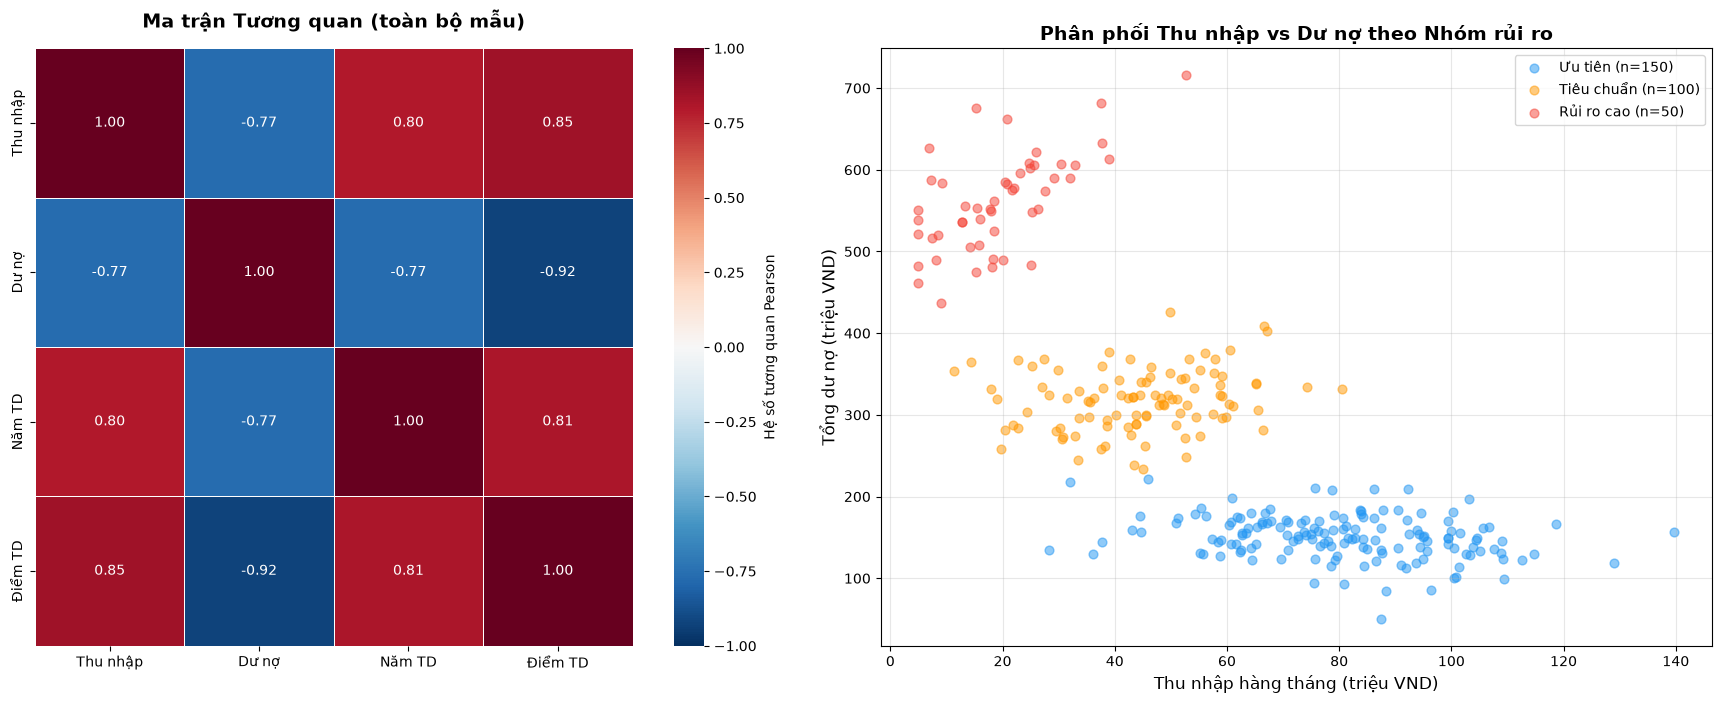


Ma trận tương quan:
               Thu_nhap  Du_no  Nam_tin_dung  Diem_tin_dung
Thu_nhap          1.000 -0.773         0.803          0.847
Du_no            -0.773  1.000        -0.773         -0.923
Nam_tin_dung      0.803 -0.773         1.000          0.815
Diem_tin_dung     0.847 -0.923         0.815          1.000


In [2]:
# =====================================================================
# TRỰC QUAN HÓA: PAIRPLOT VÀ HEATMAP TƯƠNG QUAN
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Heatmap ma trận tương quan toàn bộ dữ liệu ---
corr_matrix = df[cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'label': 'Hệ số tương quan Pearson'},
    xticklabels=['Thu nhập', 'Dư nợ', 'Năm TD', 'Điểm TD'],
    yticklabels=['Thu nhập', 'Dư nợ', 'Năm TD', 'Điểm TD']
)
axes[0].set_title('Ma trận Tương quan (toàn bộ mẫu)', fontsize=14, fontweight='bold', pad=15)

# --- Scatter plot: Thu nhập vs Dư nợ theo nhóm (biểu đồ minh họa chính) ---
colors = {'Uu_tien': '#2196F3', 'Tieu_chuan': '#FF9800', 'Cao': '#F44336'}
labels = {'Uu_tien': 'Ưu tiên (n=150)', 'Tieu_chuan': 'Tiêu chuẩn (n=100)', 'Cao': 'Rủi ro cao (n=50)'}
for grp, color in colors.items():
    subset = df[df['Nhom_rui_ro'] == grp]
    axes[1].scatter(
        subset['Thu_nhap'], subset['Du_no'],
        c=color, alpha=0.5, s=40, label=labels[grp]
    )
axes[1].set_xlabel('Thu nhập hàng tháng (triệu VND)', fontsize=12)
axes[1].set_ylabel('Tổng dư nợ (triệu VND)', fontsize=12)
axes[1].set_title('Phân phối Thu nhập vs Dư nợ theo Nhóm rủi ro', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/chapter1_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nMa trận tương quan:\n{corr_matrix.round(3).to_string()}")

### 1.5.3. Phân tích cấu trúc Eigenvalue của Ma trận Hiệp phương sai

Từ quan sát trực quan, chúng ta bước sang phân tích định lượng cốt lõi: eigendecomposition của ma trận hiệp phương sai mẫu $\mathbf{S}$. Đây là bước chuyển đổi ngôn ngữ, từ ngôn ngữ của "các biến đo lường" sang ngôn ngữ của "các chiều thông tin thực sự". Hàm `numpy.linalg.eigh` được sử dụng thay vì `eig` vì `eigh` được tối ưu hóa cho ma trận đối xứng thực (symmetric real matrix) — đảm bảo rằng tất cả eigenvalues trả về đều là số thực không âm, phù hợp với tính chất nửa xác định dương (positive semi-definite) của $\mathbf{S}$.

Kết quả của phép phân tích này sẽ trả lời câu hỏi quan trọng nhất trong bất kỳ bài toán giảm chiều nào: **bao nhiêu thành phần chính là đủ để nắm giữ phần lớn thông tin của dữ liệu?** Nếu Thành phần chính thứ nhất và thứ hai cộng lại đã giải thích được hơn 80% tổng phương sai, điều đó có nghĩa là 4 biến ban đầu của chúng ta thực ra chỉ mang 2 chiều thông tin thực sự độc lập — một phát hiện có ý nghĩa lớn đối với việc xây dựng mô hình tín dụng gọn nhẹ và diễn giải được.

PC       Eigenvalue    PVE (%)  Cumulative (%)
PC1          3.4798      86.70           86.70
PC2          0.2692       6.71           93.41
PC3          0.1989       4.96           98.37
PC4          0.0655       1.63          100.00

Tổng eigenvalues = 4.0134 (= số biến p = 4)


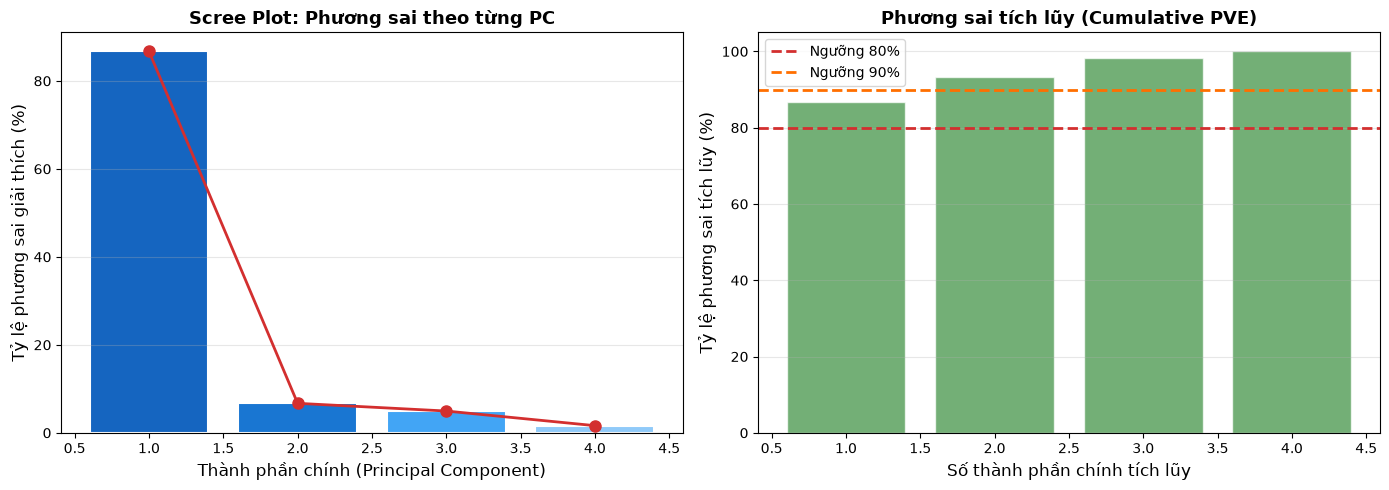


Eigenvectors (loadings của 4 PC):
                 PC1    PC2    PC3    PC4
Thu_nhap      -0.493 -0.419 -0.733  0.210
Du_no          0.501 -0.622 -0.149 -0.584
Nam_tin_dung  -0.488 -0.571  0.660  0.021
Diem_tin_dung -0.517  0.336 -0.068 -0.784


In [3]:
# =====================================================================
# EIGENDECOMPOSITION CỦA MA TRẬN HIỆP PHƯƠNG SAI MẪU
# =====================================================================

# Chuẩn hóa dữ liệu trước khi tính (để eigenvalues có thể so sánh được)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols])

# Tính ma trận hiệp phương sai mẫu (đã chuẩn hóa = ma trận tương quan)
S = np.cov(X_scaled.T)  # shape: (p, p) với p=4

# Eigendecomposition — eigh trả về giá trị tăng dần, đảo ngược để giảm dần
eigenvalues, eigenvectors = np.linalg.eigh(S)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# Tỷ lệ phương sai được giải thích
PVE = eigenvalues / eigenvalues.sum()
cumPVE = PVE.cumsum()

print("=" * 55)
print(f"{'PC':<6} {'Eigenvalue':>12} {'PVE (%)':>10} {'Cumulative (%)':>15}")
print("=" * 55)
for k in range(len(eigenvalues)):
    print(f"PC{k+1:<4} {eigenvalues[k]:>12.4f} {PVE[k]*100:>10.2f} {cumPVE[k]*100:>15.2f}")
print("=" * 55)
print(f"\nTổng eigenvalues = {eigenvalues.sum():.4f} (= số biến p = {len(eigenvalues)})")

# Trực quan hóa Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 5), PVE*100, color=['#1565C0','#1976D2','#42A5F5','#90CAF9'],
            edgecolor='white', linewidth=1.5)
axes[0].plot(range(1, 5), PVE*100, 'o-', color='#D32F2F', linewidth=2, markersize=8)
axes[0].set_xlabel('Thành phần chính (Principal Component)', fontsize=12)
axes[0].set_ylabel('Tỷ lệ phương sai giải thích (%)', fontsize=12)
axes[0].set_title('Scree Plot: Phương sai theo từng PC', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1, 5), cumPVE*100, color='#388E3C', alpha=0.7, edgecolor='white')
axes[1].axhline(y=80, color='#D32F2F', linestyle='--', linewidth=2, label='Ngưỡng 80%')
axes[1].axhline(y=90, color='#FF6F00', linestyle='--', linewidth=2, label='Ngưỡng 90%')
axes[1].set_xlabel('Số thành phần chính tích lũy', fontsize=12)
axes[1].set_ylabel('Tỷ lệ phương sai tích lũy (%)', fontsize=12)
axes[1].set_title('Phương sai tích lũy (Cumulative PVE)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/chapter1_screeplot.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nEigenvectors (loadings của 4 PC):")
pc_df = pd.DataFrame(eigenvectors, index=cols,
                     columns=[f'PC{k+1}' for k in range(4)])
print(pc_df.round(3).to_string())

### 1.5.4. So sánh Khoảng cách Mahalanobis và Euclidean

Đây là thí nghiệm tư duy quan trọng nhất của toàn bộ chương 1. Chúng ta sẽ tính khoảng cách Mahalanobis và Euclidean từ mỗi khách hàng đến tâm của toàn bộ tập dữ liệu, sau đó so sánh cách hai thước đo này xếp hạng mức độ "khác thường" (outlier score) của từng khách hàng. Như đã phân tích trong mục 1.3.2, khoảng cách Euclidean bị mù trước cấu trúc tương quan và không cân bằng đơn vị đo, trong khi khoảng cách Mahalanobis tính đến cả hai yếu tố đó thông qua phép nhân với $\boldsymbol{\Sigma}^{-1}$.

Kết quả sẽ tiết lộ một nghịch lý quan trọng: những khách hàng mà Euclidean distance cho là "bình thường" (gần tâm) đôi khi lại là những ngoại lệ rủi ro nghiêm trọng nhất theo Mahalanobis distance. Điều này xảy ra vì Euclidean distance không nhận ra rằng "thu nhập cao + dư nợ cao" là một hồ sơ bất thường trong bối cảnh tập dữ liệu — nơi mà thu nhập và dư nợ thường có tương quan âm. Mahalanobis distance, thông qua $\boldsymbol{\Sigma}^{-1}$, phát hiện chính xác sự bất thường này và gán điểm outlier cao hơn một cách đúng đắn.

Eigenvalues nhỏ nhất của S: 5.2183 (> 0 → khả nghịch)

Khách hàng được Euclidean đánh giá 'an toàn' nhưng Mahalanobis tiết lộ 'rủi ro cao':
    Nhom_rui_ro  Thu_nhap   Du_no  Diem_tin_dung  Rank_Mahal  Rank_Eucl  Rank_Diff
167  Tieu_chuan     52.54  345.22         703.71           8        216       -208
63      Uu_tien     84.22  148.27         634.09          18        205       -187
66      Uu_tien     51.22  174.12         775.06          19        190       -171
155  Tieu_chuan     28.36  324.18         622.98          68        235       -167
218  Tieu_chuan     56.16  375.22         617.20          74        240       -166


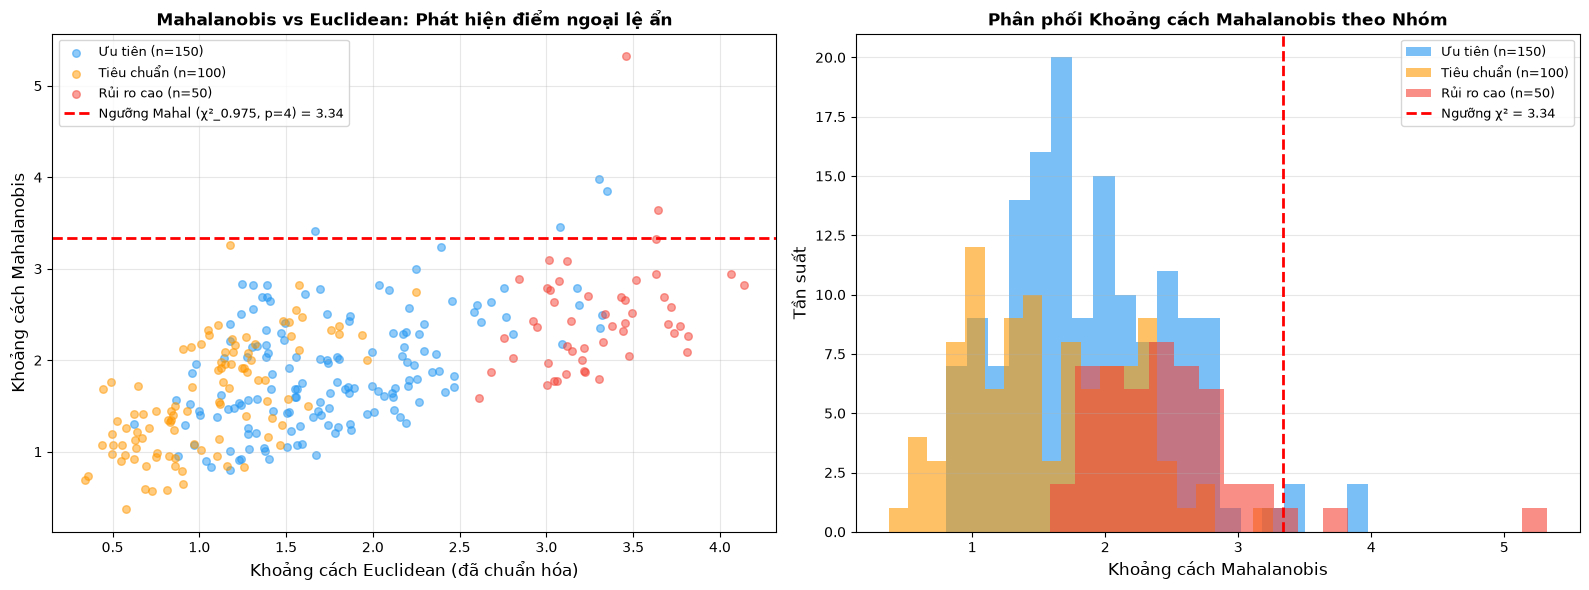

In [4]:
# =====================================================================
# SO SÁNH KHOẢNG CÁCH MAHALANOBIS VÀ EUCLIDEAN
# =====================================================================

# Tính ma trận hiệp phương sai và nghịch đảo trên dữ liệu gốc (chưa chuẩn hóa)
X_raw = df[cols].values
mean_vec = X_raw.mean(axis=0)
S_raw = np.cov(X_raw.T)

# Tính eigenvalues của S_raw để kiểm tra positive definite
eig_check = np.linalg.eigvalsh(S_raw)
print(f"Eigenvalues nhỏ nhất của S: {eig_check.min():.4f} (> 0 → khả nghịch)")

# Nghịch đảo ma trận hiệp phương sai
S_inv = np.linalg.inv(S_raw)

# Tính khoảng cách cho từng quan sát
mahal_dists = []
eucl_dists = []
for i in range(len(X_raw)):
    diff = X_raw[i] - mean_vec
    # Mahalanobis: sqrt(diff^T * S_inv * diff)
    mahal = np.sqrt(diff @ S_inv @ diff)
    # Euclidean trên dữ liệu đã chuẩn hóa (để so sánh công bằng)
    eucl = np.linalg.norm(X_scaled[i])
    mahal_dists.append(mahal)
    eucl_dists.append(eucl)

df['Mahalanobis'] = mahal_dists
df['Euclidean_scaled'] = eucl_dists

# Xếp hạng: outlier score cao = rủi ro cao
df['Rank_Mahal'] = df['Mahalanobis'].rank(ascending=False).astype(int)
df['Rank_Eucl'] = df['Euclidean_scaled'].rank(ascending=False).astype(int)

# Phát hiện các quan sát có RANK KHÁC NHAU nhiều nhất (Mahal cao, Eucl thấp)
df['Rank_Diff'] = df['Rank_Mahal'] - df['Rank_Eucl']
hidden_risks = df[df['Rank_Diff'] < -30].nsmallest(5, 'Rank_Diff')[
    ['Nhom_rui_ro','Thu_nhap','Du_no','Diem_tin_dung','Rank_Mahal','Rank_Eucl','Rank_Diff']
]
print("\nKhách hàng được Euclidean đánh giá 'an toàn' nhưng Mahalanobis tiết lộ 'rủi ro cao':")
print(hidden_risks.round(2).to_string())

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Mahal vs Euclidean, tô màu theo nhóm
for grp, color in colors.items():
    subset = df[df['Nhom_rui_ro'] == grp]
    axes[0].scatter(subset['Euclidean_scaled'], subset['Mahalanobis'],
                    c=color, alpha=0.5, s=30, label=labels[grp])
chi2_threshold = np.sqrt(stats.chi2.ppf(0.975, df=4))
axes[0].axhline(y=chi2_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Ngưỡng Mahal (χ²_0.975, p=4) = {chi2_threshold:.2f}')
axes[0].set_xlabel('Khoảng cách Euclidean (đã chuẩn hóa)', fontsize=12)
axes[0].set_ylabel('Khoảng cách Mahalanobis', fontsize=12)
axes[0].set_title('Mahalanobis vs Euclidean: Phát hiện điểm ngoại lệ ẩn', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Histogram Mahalanobis distances theo nhóm
for grp, color in colors.items():
    subset = df[df['Nhom_rui_ro'] == grp]
    axes[1].hist(subset['Mahalanobis'], bins=20, alpha=0.6, color=color, label=labels[grp])
axes[1].axvline(x=chi2_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Ngưỡng χ² = {chi2_threshold:.2f}')
axes[1].set_xlabel('Khoảng cách Mahalanobis', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].set_title('Phân phối Khoảng cách Mahalanobis theo Nhóm', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/chapter1_mahalanobis.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.5.5. Kiểm định tính Chuẩn đa biến (Chi-squared Q-Q Plot)

Bước cuối cùng trong pipeline thực hành là kiểm định xem dữ liệu có tuân theo phân phối chuẩn đa biến hay không — giả định nền tảng của MANOVA, LDA, CFA và nhiều kỹ thuật khác sẽ được sử dụng trong các chương sau. Phương pháp trực quan chuẩn mực nhất là vẽ **Chi-squared Q-Q plot**: nếu dữ liệu thực sự tuân theo phân phối chuẩn đa biến, thì theo lý thuyết (mục 1.3.1), khoảng cách Mahalanobis bình phương $D_i^2$ của mỗi quan sát sẽ tuân theo phân phối $\chi^2_p$. Do đó, đồ thị phân tán giữa các phân vị quan sát được (observed quantiles của $D_i^2$) và các phân vị lý thuyết của $\chi^2_p$ sẽ nằm gần đường thẳng 45° nếu giả định chuẩn được thỏa mãn.

Trong thực tế phân tích tín dụng, dữ liệu hầu như không bao giờ tuân theo chuẩn đa biến hoàn hảo — đặc biệt ở vùng đuôi phân phối (tail region) nơi mà những khách hàng cực kỳ rủi ro hoặc cực kỳ an toàn tập trung. Sự lệch khỏi đường thẳng 45° ở phần đuôi trên của đồ thị là tín hiệu rõ ràng cho thấy phân phối có đuôi dày hơn (heavy-tailed) so với chuẩn đa biến — một đặc tính phổ biến của dữ liệu tài chính và là lý do vì sao các nhà phân tích rủi ro hiện đại thường bổ sung bước kiểm định Mardia hoặc Henze-Zirkler trước khi chọn phương pháp phân tích.

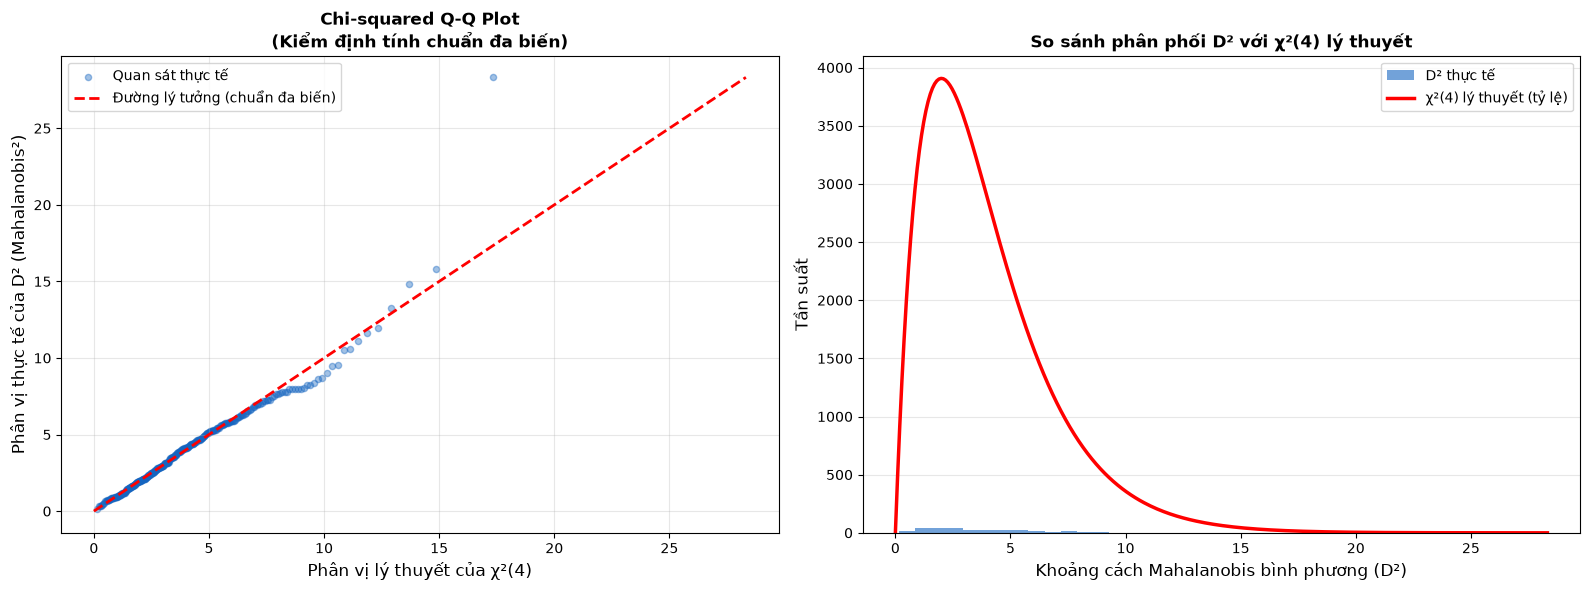

Mardia Kurtosis (b_2,p): 24.684 (kỳ vọng lý thuyết: 24)
Tỷ lệ quan sát D² > chi2_0.975: 2.0% (kỳ vọng: 2.5%)


In [5]:
# =====================================================================
# KIỂM ĐỊNH TÍNH CHUẨN ĐA BIẾN: CHI-SQUARED Q-Q PLOT
# =====================================================================

# Tính D^2 (Mahalanobis bình phương) cho dữ liệu chuẩn hóa
p = X_scaled.shape[1]  # số biến = 4
S_scaled = np.cov(X_scaled.T)
S_scaled_inv = np.linalg.inv(S_scaled)
mean_scaled = X_scaled.mean(axis=0)

D2 = np.array([
    (X_scaled[i] - mean_scaled) @ S_scaled_inv @ (X_scaled[i] - mean_scaled)
    for i in range(len(X_scaled))
])

# Sắp xếp D^2 tăng dần để so sánh với phân vị chi-squared
D2_sorted = np.sort(D2)
n = len(D2_sorted)

# Phân vị lý thuyết từ phân phối chi-squared với p bậc tự do
chi2_quantiles = stats.chi2.ppf((np.arange(1, n+1) - 0.5) / n, df=p)

# Vẽ đồ thị
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chi-squared Q-Q Plot
axes[0].scatter(chi2_quantiles, D2_sorted, alpha=0.4, s=20, color='#1565C0', label='Quan sát thực tế')
max_val = max(chi2_quantiles.max(), D2_sorted.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Đường lý tưởng (chuẩn đa biến)')
axes[0].set_xlabel(f'Phân vị lý thuyết của χ²({p})', fontsize=12)
axes[0].set_ylabel('Phân vị thực tế của D² (Mahalanobis²)', fontsize=12)
axes[0].set_title('Chi-squared Q-Q Plot\n(Kiểm định tính chuẩn đa biến)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Phân phối D² vs Chi-squared lý thuyết
x_range = np.linspace(0, D2.max(), 300)
chi2_pdf = stats.chi2.pdf(x_range, df=p) * n * (D2.max() / 60)
axes[1].hist(D2, bins=40, density=False, alpha=0.6, color='#1565C0', label='D² thực tế')
axes[1].plot(x_range, chi2_pdf * n * 0.5, 'r-', linewidth=2.5, label=f'χ²({p}) lý thuyết (tỷ lệ)')
axes[1].set_xlabel('Khoảng cách Mahalanobis bình phương (D²)', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].set_title('So sánh phân phối D² với χ²(4) lý thuyết', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/chapter1_qqplot.png', dpi=120, bbox_inches='tight')
plt.show()

# Kiểm định định lượng đơn giản: Mardia's kurtosis (xấp xỉ)
n_obs = len(X_scaled)
b2p = np.mean(D2**2)  # Mardia kurtosis statistic (approximate)
expected_b2p = p * (p + 2)
print(f"Mardia Kurtosis (b_2,p): {b2p:.3f} (kỳ vọng lý thuyết: {expected_b2p})")
print(f"Tỷ lệ quan sát D² > chi2_0.975: {(D2 > stats.chi2.ppf(0.975, p)).mean()*100:.1f}% (kỳ vọng: 2.5%)")

## Case Study Ứng dụng

### Phân tích Rủi ro Tín dụng Đa chiều: Phát hiện Khách hàng có Rủi ro Tiềm ẩn

Case study này hiện thực hóa trực tiếp toàn bộ bộ công cụ lý thuyết và thực hành đã xây dựng trong chương 1 vào một bài toán phân tích rủi ro tín dụng hoàn chỉnh từ đầu đến cuối. Bài toán được đặt ra như sau: một ngân hàng thương mại có tập dữ liệu gồm 500 hồ sơ khách hàng cũ, mỗi hồ sơ bao gồm các chỉ số tài chính đa chiều và kết quả vay (đã vỡ nợ hay không). Nhiệm vụ của nhóm phân tích là xây dựng một hệ thống cảnh báo sớm (early warning system) dựa trên khoảng cách Mahalanobis — phát hiện những khách hàng hiện tại có hồ sơ tài chính "bất thường" theo nghĩa đa chiều, tức là những người nằm xa tâm của nhóm khách hàng tốt trong không gian đa biến.

Điểm then chốt của phương pháp này là nó không cần một mô hình phân loại có giám sát (supervised classifier). Thay vào đó, nó chỉ cần học "hình dạng" của đám mây điểm khách hàng tốt (good clients) trong không gian $p$-chiều — tức là ma trận hiệp phương sai của nhóm đó — và sau đó đo xem mỗi khách hàng mới xa trung tâm của nhóm tốt bao nhiêu. Khoảng cách Mahalanobis lớn (vượt ngưỡng $\chi^2$ thống kê) là tín hiệu cảnh báo: khách hàng này không "thuộc về" nhóm tốt theo nghĩa đa chiều, dù từng biến đơn lẻ có thể trông bình thường.

In [6]:
# =====================================================================
# CASE STUDY: HỆ THỐNG CẢNH BÁO SỚM RỦI RO TÍN DỤNG ĐA CHIỀU
# Dataset: credit_risk_simulated.csv
# =====================================================================
import os

DATASET_PATH = r'..\case_studies\00_main_bank_churn\credit_risk_simulated.csv'

# Tạo dữ liệu mô phỏng nếu file chưa tồn tại
if not os.path.exists(DATASET_PATH):
    np.random.seed(2024)
    n_good, n_bad = 400, 100
    
    # Khách hàng tốt: thu nhập ổn định, nợ hợp lý, lịch sử tốt
    mu_good = [60, 180, 10, 720, 35, 3]
    Sigma_good = np.diag([400, 1600, 9, 2500, 25, 1]) 
    Sigma_good[0,1] = Sigma_good[1,0] = -300  # thu nhập ~ nợ: tương quan âm
    Sigma_good[0,3] = Sigma_good[3,0] = 500   # thu nhập ~ điểm: tương quan dương
    good_data = np.random.multivariate_normal(mu_good, Sigma_good, n_good)
    
    # Khách hàng xấu: đa dạng hơn, đuôi phân phối nặng hơn
    mu_bad = [30, 450, 4, 450, 58, 7]
    Sigma_bad = np.diag([900, 4900, 16, 4000, 100, 4])
    Sigma_bad[0,1] = Sigma_bad[1,0] = 500   # thu nhập ~ nợ: tương quan dương (nguy hiểm!)
    bad_data = np.random.multivariate_normal(mu_bad, Sigma_bad, n_bad)
    
    feature_cols = ['Thu_nhap', 'Du_no', 'Nam_tin_dung', 'Diem_tin_dung', 'DTI_ratio', 'So_lan_tre_han']
    
    df_case = pd.DataFrame(
        np.vstack([good_data, bad_data]),
        columns=feature_cols
    )
    df_case['Vo_no'] = [0]*n_good + [1]*n_bad
    df_case['Thu_nhap'] = df_case['Thu_nhap'].clip(lower=5)
    df_case['Du_no'] = df_case['Du_no'].clip(lower=0)
    df_case['Nam_tin_dung'] = df_case['Nam_tin_dung'].clip(lower=0)
    df_case['Diem_tin_dung'] = df_case['Diem_tin_dung'].clip(150, 850)
    df_case['DTI_ratio'] = df_case['DTI_ratio'].clip(0, 100)
    df_case['So_lan_tre_han'] = df_case['So_lan_tre_han'].clip(lower=0).round()
    
    os.makedirs(os.path.dirname(DATASET_PATH), exist_ok=True)
    df_case.to_csv(DATASET_PATH, index=False, encoding='utf-8')
    print(f"Đã tạo và lưu dataset: {DATASET_PATH}")

# Đọc dữ liệu
df_case = pd.read_csv(DATASET_PATH)
feature_cols = ['Thu_nhap', 'Du_no', 'Nam_tin_dung', 'Diem_tin_dung', 'DTI_ratio', 'So_lan_tre_han']
print(f"\nDataset: {df_case.shape[0]} quan sát × {df_case.shape[1]} biến")
print(f"Tỷ lệ vỡ nợ: {df_case['Vo_no'].mean()*100:.1f}%")
print(f"\nThống kê mô tả:\n{df_case[feature_cols].describe().round(2).to_string()}")


Dataset: 500 quan sát × 7 biến
Tỷ lệ vỡ nợ: 20.0%

Thống kê mô tả:
       Thu_nhap   Du_no  Nam_tin_dung  Diem_tin_dung  DTI_ratio  So_lan_tre_han
count    500.00  500.00        500.00         500.00     500.00          500.00
mean      55.81  237.53          9.11         667.85      39.53            3.84
std       22.45  118.57          3.80         120.75      11.17            1.99
min        5.00    6.81          0.00         309.23      18.35            0.00
25%       40.34  167.80          6.79         642.01      32.29            3.00
50%       58.24  194.74          9.44         706.36      36.30            3.00
75%       72.41  238.90         11.92         745.62      42.97            4.00
max      112.72  602.71         17.26         850.00      93.06           11.00


### Phân tích Khám phá Dữ liệu (EDA)

Bước Phân tích Khám phá Dữ liệu giúp chúng ta có cái nhìn tổng quan về phân phối, các giá trị khuyết thiếu và cấu trúc tương quan giữa các biến trước khi tiến hành mô hình hóa.

--- Thông tin cơ bản df_case ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Thu_nhap        500 non-null    float64
 1   Du_no           500 non-null    float64
 2   Nam_tin_dung    500 non-null    float64
 3   Diem_tin_dung   500 non-null    float64
 4   DTI_ratio       500 non-null    float64
 5   So_lan_tre_han  500 non-null    float64
 6   Vo_no           500 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.5 KB


,Thu_nhap,Du_no,Nam_tin_dung,Diem_tin_dung,DTI_ratio,So_lan_tre_han,Vo_no
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,55.811734,237.530276,9.106339,667.853784,39.526168,3.840000,0.200000
std,22.447901,118.573174,3.801496,120.746632,11.171552,1.986528,0.400401
min,5.000000,6.812859,0.000000,309.226001,18.346841,0.000000,0.000000
25%,40.338748,167.795108,6.790592,642.005420,32.294406,3.000000,0.000000
50%,58.241140,194.740245,9.435035,706.355754,36.303421,3.000000,0.000000
75%,72.411872,238.895841,11.924349,745.617554,42.971958,4.000000,0.000000
max,112.715803,602.708013,17.263270,850.000000,93.055595,11.000000,1.000000


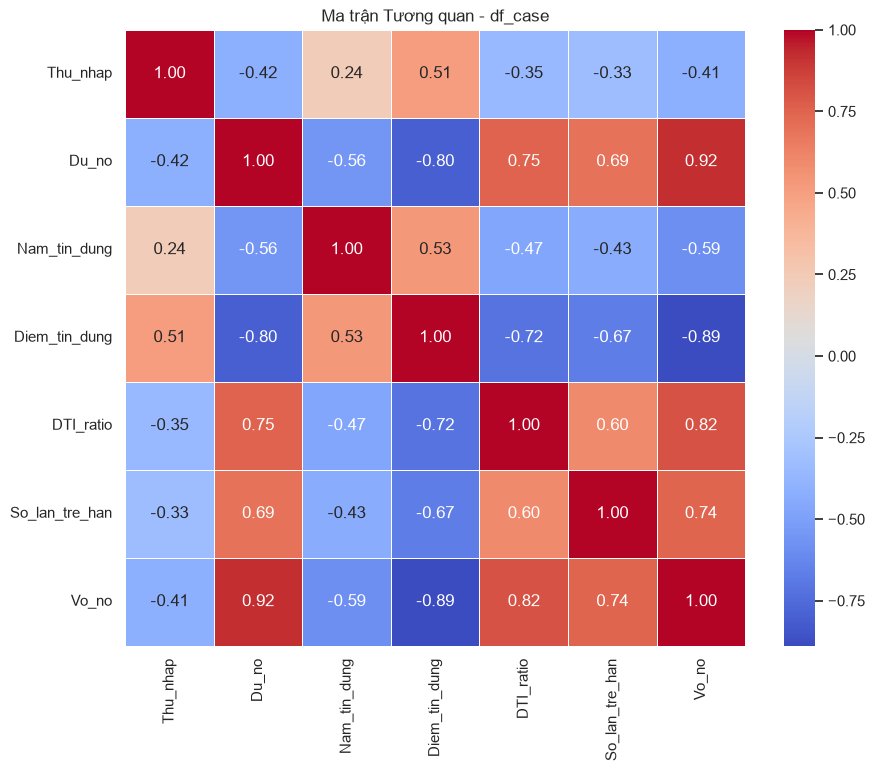

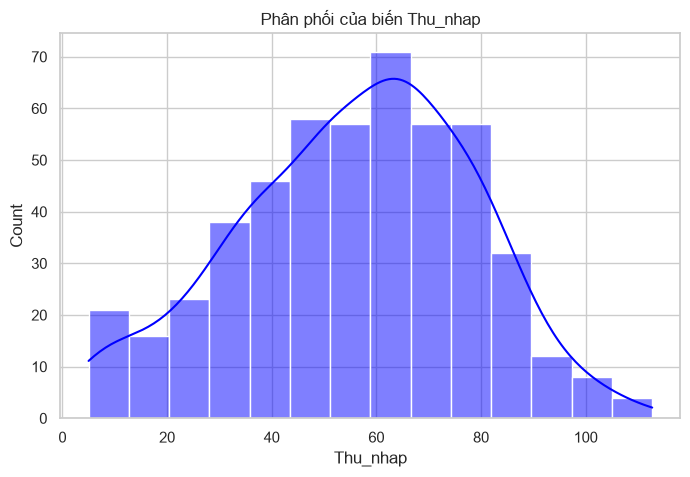

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style='whitegrid')

# 1. Thông tin cơ bản
print('--- Thông tin cơ bản df_case ---')
df_case.info()
display(df_case.describe())

# 2. Trực quan hóa Ma trận Tương quan
numeric_cols = df_case.select_dtypes(include=['float64', 'int64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_case[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Ma trận Tương quan - df_case')
    plt.savefig('images/eda_correlation_01.png', dpi=300, bbox_inches='tight')
    plt.show()

# 3. Trực quan hóa Phân phối của biến đầu tiên
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_case[numeric_cols[0]], kde=True, color='blue')
    plt.title(f'Phân phối của biến {numeric_cols[0]}')
    plt.savefig('images/eda_distribution_01.png', dpi=300, bbox_inches='tight')
    plt.show()



Ngưỡng cảnh báo D² = 14.45 (χ²_{0.975}, p=6)

Ma trận nhầm lẫn:
[[389  11]
 [  0 100]]

Báo cáo phân loại:
              precision    recall  f1-score   support

 Không vỡ nợ       1.00      0.97      0.99       400
       Vỡ nợ       0.90      1.00      0.95       100

    accuracy                           0.98       500
   macro avg       0.95      0.99      0.97       500
weighted avg       0.98      0.98      0.98       500



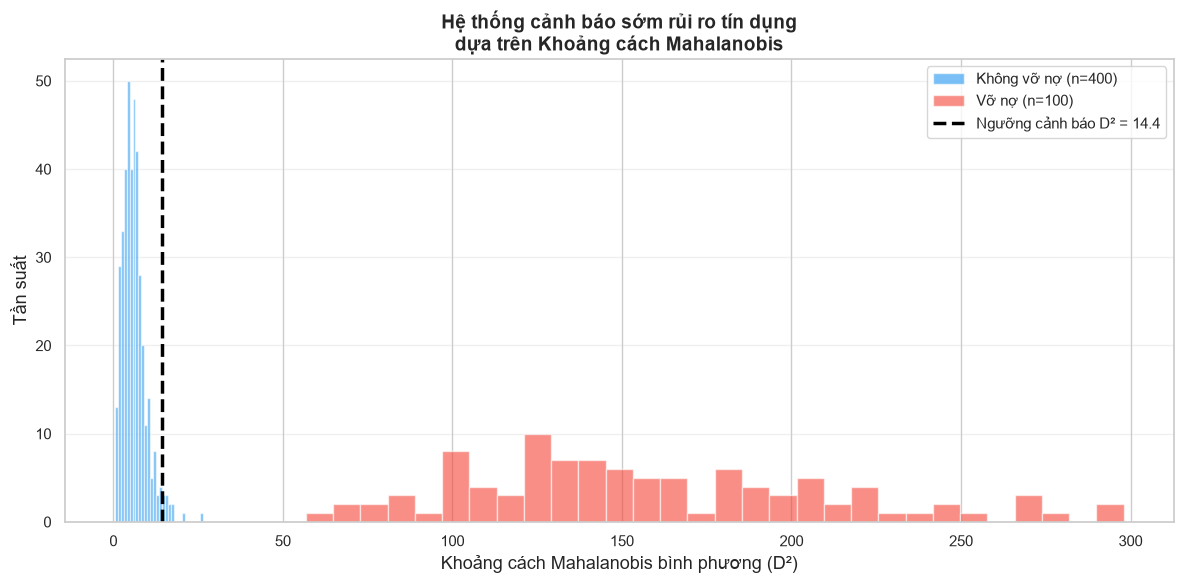

In [8]:
# =====================================================================
# XÂY DỰNG HỆ THỐNG CẢNH BÁO SỚM DỰA TRÊN MAHALANOBIS DISTANCE
# =====================================================================

# Chỉ học "hình dạng" từ nhóm khách hàng TỐT (không vỡ nợ)
good_clients = df_case[df_case['Vo_no'] == 0][feature_cols].values
mu_good_est = good_clients.mean(axis=0)
S_good_est = np.cov(good_clients.T)
S_good_inv = np.linalg.inv(S_good_est)

# Áp dụng cho TOÀN BỘ dataset (bao gồm cả khách hàng xấu)
all_X = df_case[feature_cols].values
D2_case = np.array([
    (all_X[i] - mu_good_est) @ S_good_inv @ (all_X[i] - mu_good_est)
    for i in range(len(all_X))
])
df_case['D2_Mahal'] = D2_case

# Ngưỡng cảnh báo: phân vị 97.5% của chi-squared với p=6 bậc tự do
p_case = len(feature_cols)
threshold = stats.chi2.ppf(0.975, df=p_case)
df_case['Canh_bao'] = (df_case['D2_Mahal'] > threshold).astype(int)

# Đánh giá hiệu suất hệ thống cảnh báo
from sklearn.metrics import classification_report, confusion_matrix

print(f"\nNgưỡng cảnh báo D² = {threshold:.2f} (χ²_{{0.975}}, p={p_case})")
print(f"\nMa trận nhầm lẫn:")
print(confusion_matrix(df_case['Vo_no'], df_case['Canh_bao']))
print(f"\nBáo cáo phân loại:")
print(classification_report(df_case['Vo_no'], df_case['Canh_bao'],
                             target_names=['Không vỡ nợ', 'Vỡ nợ']))

# Phân phối D² theo nhóm
fig, ax = plt.subplots(figsize=(12, 6))
for vo_no, color, label in [(0, '#2196F3', 'Không vỡ nợ'), (1, '#F44336', 'Vỡ nợ')]:
    subset = df_case[df_case['Vo_no'] == vo_no]['D2_Mahal']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'{label} (n={len(subset)})')
ax.axvline(x=threshold, color='black', linestyle='--', linewidth=2.5,
           label=f'Ngưỡng cảnh báo D² = {threshold:.1f}')
ax.set_xlabel('Khoảng cách Mahalanobis bình phương (D²)', fontsize=13)
ax.set_ylabel('Tần suất', fontsize=13)
ax.set_title('Hệ thống cảnh báo sớm rủi ro tín dụng\ndựa trên Khoảng cách Mahalanobis', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/chapter1_casestudy.png', dpi=120, bbox_inches='tight')
plt.show()

## Câu hỏi & Bài tập

**Câu hỏi 1 — Lý thuyết (Phân tích đa biến vs đơn biến):** Một chuyên viên phân tích đề xuất đánh giá rủi ro tín dụng bằng cách xây dựng 6 mô hình đơn biến riêng lẻ — mỗi mô hình dự báo xác suất vỡ nợ dựa trên một biến duy nhất — rồi lấy trung bình cộng 6 xác suất đó. Hãy phản biện đề xuất này bằng ít nhất 3 lập luận toán học hoặc thống kê cụ thể. Trong lập luận của bạn, hãy sử dụng khái niệm joint distribution, covariance structure, và Omitted Variable Bias.

**Câu hỏi 2 — Toán học (Eigenvalues và Phương sai):** Cho ma trận hiệp phương sai $\mathbf{S} = \begin{pmatrix} 4 & 2 \\ 2 & 3 \end{pmatrix}$. (a) Tính eigenvalues và eigenvectors của $\mathbf{S}$. (b) Tính tỷ lệ phương sai được giải thích bởi PC1 và PC2. (c) Vẽ phác thảo tay các elipsoid đường đẳng mật độ tương ứng với ma trận này và chỉ ra hướng của hai eigenvectors trên đó. (d) Nếu thêm một biến thứ ba có tương quan hoàn hảo ($r = 1$) với biến thứ nhất, eigenvalue nhỏ nhất của ma trận hiệp phương sai mới sẽ là bao nhiêu? Điều này nói lên điều gì về Multicollinearity?

**Câu hỏi 3 — Bài tập lập trình:** Sử dụng dataset `credit_risk_simulated.csv` (đã được tạo trong case study), hãy hoàn thành pipeline phân tích sau trong Jupyter Notebook:
1. Tải dữ liệu và tính ma trận tương quan. Xác định cặp biến nào có tương quan cao nhất ($|r| > 0.6$) và giải thích ý nghĩa kinh tế của tương quan đó.
2. Thực hiện eigendecomposition của ma trận hiệp phương sai. Cần bao nhiêu thành phần chính để giải thích tối thiểu 80% phương sai?
3. Tính khoảng cách Mahalanobis cho từng khách hàng. Xác định top 10 khách hàng có khoảng cách lớn nhất. Trong số đó, bao nhiêu người đã thực sự vỡ nợ? So sánh với khoảng cách Euclidean.

**Câu hỏi 4 — Mở rộng tư duy:** Trong phân tích tài chính, tại sao khoảng cách Mahalanobis lại được ưu tiên hơn khoảng cách Euclidean khi phát hiện ngoại lệ (outlier detection)? Hãy trả lời bằng cách trình bày một tình huống cụ thể trong quản lý danh mục đầu tư (portfolio management) — nơi mà một tài sản trông có vẻ "bình thường" theo Euclidean nhưng thực ra là "ngoại lệ nguy hiểm" theo Mahalanobis — và giải thích tại sao sự nhầm lẫn này có thể dẫn đến tổn thất tài chính nghiêm trọng.

## Tóm tắt nội dung (Key Takeaways)

- **Tư duy đa chiều là bắt buộc**: Phân tích đơn biến (univariate) chỉ xét phân phối biên (marginal distribution) của từng biến riêng lẻ, bỏ qua hoàn toàn cấu trúc tương quan (covariance structure). Trong kinh tế và tài chính, phần lớn thông tin quan trọng nằm ở chính cấu trúc đó — không phải ở từng biến đơn lẻ.

- **Mỗi quan sát là một điểm trong không gian $p$-chiều**: Ngôn ngữ toán học của đại số tuyến tính — không gian vector, tổ hợp tuyến tính, phép chiếu trực giao — cung cấp bộ công cụ mô tả chính xác nhất cho dữ liệu đa biến. Ma trận dữ liệu $\mathbf{X}_{n \times p}$ là đối tượng trung tâm của toàn bộ phân tích.

- **OLS là một phép chiếu hình học**: Lời giải $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ là hình chiếu trực giao của $\mathbf{y}$ lên không gian cột của $\mathbf{X}$. Multicollinearity xảy ra khi $\det(\mathbf{X}^T\mathbf{X}) \approx 0$ và làm cho phép chiếu này bất ổn định.

- **Eigendecomposition tiết lộ cấu trúc ẩn**: Các eigenvectors của $\mathbf{S}$ là hệ trục tọa độ tự nhiên của dữ liệu; các eigenvalues đo lường lượng thông tin (phương sai) theo từng trục đó. PCA là thuật toán giảm chiều bảo toàn phương sai tối đa bằng cách chiếu lên $m$ eigenvectors đầu tiên.

- **Mahalanobis distance vượt trội Euclidean**: Khoảng cách Mahalanobis $D^2 = (\mathbf{x} - \boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x} - \boldsymbol{\mu})$ "khử tương quan" và cân bằng đơn vị đo thông qua $\boldsymbol{\Sigma}^{-1}$. Nó tuân theo phân phối $\chi^2_p$ dưới giả định chuẩn đa biến, cho phép kiểm định thống kê chặt chẽ về tính ngoại lệ.

- **Phân loại kỹ thuật là bước đầu tiên khi thiết kế phân tích**: Trước khi chọn bất kỳ phương pháp nào, câu hỏi đầu tiên là: bài toán có biến kết quả $Y$ rõ ràng không? Nếu có → Dependence Techniques (Hồi quy, LDA, SEM); nếu không → Interdependence Techniques (PCA, EFA, Cluster Analysis). Nhầm loại dẫn đến sai lầm mang tính phương pháp luận.

- **Giả định chuẩn đa biến phải được kiểm định**: Chi-squared Q-Q plot và kiểm định Mardia là hai công cụ chuẩn mực. Vi phạm giả định chuẩn ở vùng đuôi phân phối (tail) là cực kỳ phổ biến trong dữ liệu tài chính và đòi hỏi các phương pháp phi tham số hoặc robust alternatives.

- **Chương 2 sẽ giải quyết**: Dữ liệu thực tế không bao giờ hoàn hảo như lý thuyết — nó chứa giá trị khuyết (missing values), ngoại lệ (outliers), biến phân loại và vấn đề phân phối phi chuẩn. Chương 2 sẽ xây dựng pipeline chuẩn bị và làm sạch dữ liệu (Data Preparation & Cleaning) — điều kiện tiên quyết để các kỹ thuật trong Chương 1 hoạt động đúng như lý thuyết.